# Exploratory Data Analysis (EDA)

## Mutual Fund Analytics — Day 5

This notebook performs exploratory data analysis on the mutual fund dataset.

### EDA Objectives

1. NAV trend analysis for all 40 mutual fund schemes from 2022–2026.
2. AUM growth analysis by fund house from 2022–2025.
3. Monthly SIP inflow trend from January 2022 to December 2025.
4. Category-wise monthly net inflow analysis.
5. Investor demographic analysis.
6. Geographic distribution of investor SIP activity.
7. Industry folio count growth analysis.
8. NAV return correlation analysis for selected funds.
9. Sector allocation analysis across equity funds.
10. Document key findings from the EDA with supporting charts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

# Project paths
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = BASE_DIR / "reports"

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

# Plot settings
sns.set_theme(style="whitegrid")

print("EDA environment initialized successfully.")

EDA environment initialized successfully.


In [2]:
from pathlib import Path

PROJECT_DIR = Path.cwd().parents[1]

DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_DIR / "reports"

print("Project directory:", PROJECT_DIR)
print("NAV file exists:", (PROCESSED_DIR / "nav_history_cleaned.csv").exists())

Project directory: c:\Users\DELL\OneDrive\Desktop\MutualFundAnalytics
NAV file exists: True


In [3]:
nav_df = pd.read_csv(
    PROCESSED_DIR / "nav_history_cleaned.csv"
)

nav_df["date"] = pd.to_datetime(
    nav_df["date"],
    errors="coerce"
)

print("NAV dataset shape:", nav_df.shape)
print("Number of schemes:", nav_df["amfi_code"].nunique())
print(
    "Date range:",
    nav_df["date"].min().date(),
    "to",
    nav_df["date"].max().date()
)
print("Missing NAV values:", nav_df["nav"].isna().sum())
print("Non-positive NAV values:", (nav_df["nav"] <= 0).sum())

NAV dataset shape: (46000, 3)
Number of schemes: 40
Date range: 2022-01-03 to 2026-05-29
Missing NAV values: 0
Non-positive NAV values: 0


In [4]:
# Requirement 1: NAV Trend Analysis
# Report-ready version

nav_plot_df = nav_df.copy()
nav_plot_df["scheme"] = nav_plot_df["amfi_code"].astype(str)

fig = px.line(
    nav_plot_df,
    x="date",
    y="nav",
    color="scheme",
    title="Daily NAV Trends — 40 Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV",
        "scheme": "AMFI Code"
    }
)

# Highlight 2023 bull-run period
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.08,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 market-correction period
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.08,
    line_width=0,
    annotation_text="2024 Market Corrections",
    annotation_position="top left"
)

fig.update_layout(
    template="plotly_white",
    hovermode="x unified",
    width=1400,
    height=800,
    title={
        "text": "Daily NAV Trends — 40 Mutual Fund Schemes (2022–2026)",
        "x": 0.5,
        "xanchor": "center"
    },
    legend={
        "title": "AMFI Code",
        "orientation": "v"
    },
    margin=dict(l=70, r=180, t=90, b=70)
)

fig.show()

# Save report-ready PNG
output_path = REPORTS_DIR / "nav_trend_all_40_schemes.png"

fig.write_image(
    str(output_path),
    width=1400,
    height=800,
    scale=2
)

print("Saved:", output_path)

Saved: c:\Users\DELL\OneDrive\Desktop\MutualFundAnalytics\reports\nav_trend_all_40_schemes.png


In [5]:
# Requirement 2 — AUM Growth Data Verification

aum_df = pd.read_csv(
    PROJECT_DIR / "data" / "raw" / "03_aum_by_fund_house.csv"
)

aum_df["date"] = pd.to_datetime(aum_df["date"], errors="coerce")

print("AUM DATA SHAPE:", aum_df.shape)
print("FUND HOUSES:", aum_df["fund_house"].nunique())
print(
    "DATE RANGE:",
    aum_df["date"].min().date(),
    "to",
    aum_df["date"].max().date()
)

print("\nCOLUMNS:")
print(aum_df.columns.tolist())

print("\nMISSING VALUES:")
print(aum_df.isna().sum())

print("\nYEAR RANGE:")
print(sorted(aum_df["date"].dt.year.dropna().unique()))

print("\nFUND HOUSES:")
print(sorted(aum_df["fund_house"].dropna().unique()))

print("\nSAMPLE DATA:")
print(aum_df.head().to_string(index=False))

AUM DATA SHAPE: (90, 5)
FUND HOUSES: 10
DATE RANGE: 2022-03-31 to 2025-12-31

COLUMNS:
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

MISSING VALUES:
date              0
fund_house        0
aum_lakh_crore    0
aum_crore         0
num_schemes       0
dtype: int64

YEAR RANGE:
[np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]

FUND HOUSES:
['Aditya Birla Sun Life MF', 'Axis Mutual Fund', 'DSP Mutual Fund', 'HDFC Mutual Fund', 'ICICI Prudential MF', 'Kotak Mahindra MF', 'Mirae Asset MF', 'Nippon India MF', 'SBI Mutual Fund', 'UTI Mutual Fund']

SAMPLE DATA:
      date          fund_house  aum_lakh_crore  aum_crore  num_schemes
2022-03-31     SBI Mutual Fund            6.05     605000          186
2022-03-31 ICICI Prudential MF            4.65     465000          216
2022-03-31    HDFC Mutual Fund            4.35     435000          195
2022-03-31     Nippon India MF            2.70     270000          177
2022-03-31   Kotak Mahindra MF            2.70

YEARLY AUM DATA:
 year               fund_house  aum_lakh_crore
 2022          SBI Mutual Fund            6.30
 2022      ICICI Prudential MF            4.88
 2022         HDFC Mutual Fund            4.45
 2022 Aditya Birla Sun Life MF            2.85
 2022          Nippon India MF            2.78
 2022        Kotak Mahindra MF            2.72
 2022         Axis Mutual Fund            2.40
 2022          UTI Mutual Fund            2.32
 2022          DSP Mutual Fund            1.12
 2022           Mirae Asset MF            1.08
 2023          SBI Mutual Fund            8.45
 2023      ICICI Prudential MF            5.90
 2023         HDFC Mutual Fund            5.35
 2023          Nippon India MF            3.40
 2023        Kotak Mahindra MF            3.25
 2023 Aditya Birla Sun Life MF            3.08
 2023          UTI Mutual Fund            2.65
 2023         Axis Mutual Fund            2.60
 2023           Mirae Asset MF            1.42
 2023          DSP Mutual Fund            1

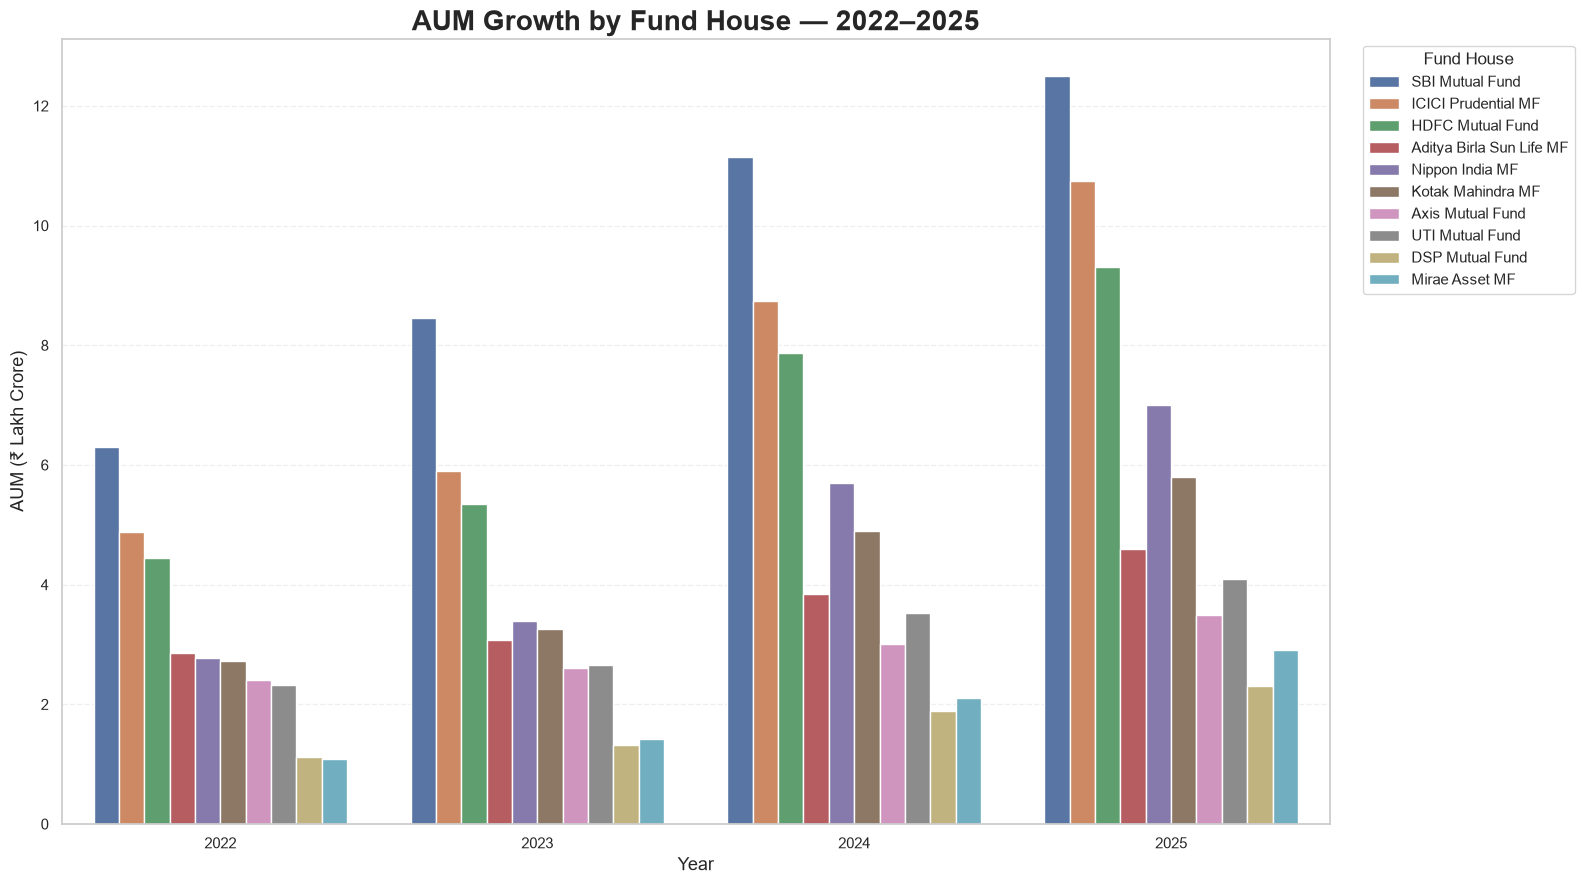


Saved: c:\Users\DELL\OneDrive\Desktop\MutualFundAnalytics\reports\aum_growth_by_fund_house.png


In [6]:
# Requirement 2 — AUM Growth by Fund House
# Grouped bar chart for 2022–2025

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load AUM data
aum_df = pd.read_csv(
    PROJECT_DIR / "data" / "raw" / "03_aum_by_fund_house.csv"
)

aum_df["date"] = pd.to_datetime(aum_df["date"], errors="coerce")
aum_df["year"] = aum_df["date"].dt.year

# Keep the latest available AUM observation for each fund house in each year
aum_yearly = (
    aum_df
    .sort_values("date")
    .groupby(["year", "fund_house"], as_index=False)
    .tail(1)
    .sort_values(["year", "aum_lakh_crore"], ascending=[True, False])
    .reset_index(drop=True)
)

# Keep only the required years
aum_yearly = aum_yearly[
    aum_yearly["year"].isin([2022, 2023, 2024, 2025])
].copy()

print("YEARLY AUM DATA:")
print(
    aum_yearly[
        ["year", "fund_house", "aum_lakh_crore"]
    ].to_string(index=False)
)

# Create grouped bar chart
plt.figure(figsize=(16, 9))

ax = sns.barplot(
    data=aum_yearly,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house",
    errorbar=None
)

plt.title(
    "AUM Growth by Fund House — 2022–2025",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel("Year", fontsize=13)
plt.ylabel("AUM (₹ Lakh Crore)", fontsize=13)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

# Save report-ready PNG
output_path = REPORTS_DIR / "aum_growth_by_fund_house.png"

plt.savefig(
    output_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nSaved:", output_path)

In [7]:
# Requirement 2 — Verify SBI dominance

sbi_2025 = aum_yearly[
    (aum_yearly["fund_house"] == "SBI Mutual Fund") &
    (aum_yearly["year"] == 2025)
]

print("SBI MUTUAL FUND — 2025 AUM")
print(
    sbi_2025[
        ["year", "fund_house", "aum_lakh_crore", "aum_crore"]
    ].to_string(index=False)
)

print("\nSBI is the highest-AUM fund house in 2025:",
      aum_yearly[aum_yearly["year"] == 2025]
      .sort_values("aum_lakh_crore", ascending=False)
      .iloc[0]["fund_house"] == "SBI Mutual Fund")

SBI MUTUAL FUND — 2025 AUM
 year      fund_house  aum_lakh_crore  aum_crore
 2025 SBI Mutual Fund            12.5    1250000

SBI is the highest-AUM fund house in 2025: True


In [8]:
# Requirement 3 — SIP Inflow Time Series
# Step 1: Load and validate SIP inflow data

sip_df = pd.read_csv(
    PROJECT_DIR / "data" / "raw" / "04_monthly_sip_inflows.csv"
)

sip_df["month"] = pd.to_datetime(sip_df["month"], errors="coerce")

print("SIP DATA SHAPE:", sip_df.shape)
print("DATE RANGE:", sip_df["month"].min().date(), "to", sip_df["month"].max().date())
print("MISSING VALUES:")
print(sip_df.isna().sum())

print("\nSAMPLE DATA:")
print(sip_df.head().to_string(index=False))

print("\nLAST 5 MONTHS:")
print(sip_df.tail().to_string(index=False))

SIP DATA SHAPE: (48, 6)
DATE RANGE: 2022-01-01 to 2025-12-01
MISSING VALUES:
month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64

SAMPLE DATA:
     month  sip_inflow_crore  active_sip_accounts_crore  new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct
2022-01-01             11517                       4.91                   9.10                4.80             NaN
2022-02-01             11438                       4.93                   8.20                4.85             NaN
2022-03-01             12328                       5.09                  10.50                5.01             NaN
2022-04-01             11863                       5.48                   9.52                5.12             NaN
2022-05-01             12286                       5.55                   8.10                5.15             NaN

LAST 5 MONTHS

In [10]:
# ============================================================
# REQUIREMENT 3 — SIP INFLOW TIME SERIES
# Monthly SIP trend: January 2022 to December 2025
# All-time high annotation: December 2025 — ₹31,002 Cr
# ============================================================

import pandas as pd
import plotly.graph_objects as go

# ------------------------------------------------------------
# 1. Load SIP inflow data
# ------------------------------------------------------------

sip_df = pd.read_csv(
    PROJECT_DIR / "data" / "raw" / "04_monthly_sip_inflows.csv"
)

# Convert month to datetime
sip_df["month"] = pd.to_datetime(
    sip_df["month"],
    errors="coerce"
)

# Sort chronologically
sip_df = sip_df.sort_values("month").reset_index(drop=True)

# ------------------------------------------------------------
# 2. Basic validation
# ------------------------------------------------------------

print("SIP DATA SHAPE:", sip_df.shape)

print(
    "DATE RANGE:",
    sip_df["month"].min().date(),
    "to",
    sip_df["month"].max().date()
)

print("\nMISSING SIP INFLOW VALUES:")
print(sip_df["sip_inflow_crore"].isna().sum())

# ------------------------------------------------------------
# 3. Find the all-time high
# ------------------------------------------------------------

max_idx = sip_df["sip_inflow_crore"].idxmax()

max_row = sip_df.loc[max_idx]

max_month = max_row["month"]
max_sip = max_row["sip_inflow_crore"]

print("\nALL-TIME HIGH SIP INFLOW:")
print("Month:", max_month.strftime("%B %Y"))
print("SIP Inflow:", f"₹{max_sip:,.0f} Cr")

# ------------------------------------------------------------
# 4. Create Plotly figure
# ------------------------------------------------------------

fig = go.Figure()

# Monthly SIP inflow line
fig.add_trace(
    go.Scatter(
        x=sip_df["month"].tolist(),
        y=sip_df["sip_inflow_crore"].tolist(),
        mode="lines+markers",
        name="Monthly SIP Inflow",
        hovertemplate=(
            "Month=%{x|%b %Y}"
            "<br>SIP Inflow=₹%{y:,.0f} Cr"
            "<extra></extra>"
        )
    )
)

# All-time-high marker
fig.add_trace(
    go.Scatter(
        x=[max_month],
        y=[max_sip],
        mode="markers",
        name="All-Time High",
        marker=dict(
            size=14
        ),
        hovertemplate=(
            "Month=%{x|%b %Y}"
            "<br>All-Time High=₹%{y:,.0f} Cr"
            "<extra></extra>"
        )
    )
)

# ------------------------------------------------------------
# 5. Annotate December 2025 all-time high
# ------------------------------------------------------------

fig.add_annotation(
    x=max_month,
    y=max_sip,
    text=(
        f"All-Time High<br>"
        f"₹{max_sip:,.0f} Cr<br>"
        f"{max_month.strftime('%b %Y')}"
    ),
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-70
)

# ------------------------------------------------------------
# 6. Chart formatting
# ------------------------------------------------------------

fig.update_layout(
    title="Monthly SIP Inflow Trend — January 2022 to December 2025",
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    template="plotly_white",
    hovermode="x unified",
    width=1400,
    height=700
)

# ------------------------------------------------------------
# 7. Display chart
# ------------------------------------------------------------

fig.show()

# ------------------------------------------------------------
# 8. Save report-ready PNG
# ------------------------------------------------------------
# Kaleido can fail when pandas Timestamp objects are passed
# directly. Convert all dates to JSON-safe ISO strings first.

export_fig = go.Figure()

export_fig.add_trace(
    go.Scatter(
        x=[
            x.strftime("%Y-%m-%d")
            if hasattr(x, "strftime")
            else str(x)
            for x in sip_df["month"]
        ],
        y=sip_df["sip_inflow_crore"].astype(float).tolist(),
        mode="lines+markers",
        name="Monthly SIP Inflow"
    )
)

export_fig.add_trace(
    go.Scatter(
        x=[
            max_month.strftime("%Y-%m-%d")
        ],
        y=[float(max_sip)],
        mode="markers",
        name="All-Time High",
        marker=dict(size=14)
    )
)

export_fig.add_annotation(
    x=max_month.strftime("%Y-%m-%d"),
    y=float(max_sip),
    text=(
        f"All-Time High<br>"
        f"₹{max_sip:,.0f} Cr<br>"
        f"{max_month.strftime('%b %Y')}"
    ),
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-70
)

export_fig.update_layout(
    title="Monthly SIP Inflow Trend — January 2022 to December 2025",
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    template="plotly_white",
    hovermode="x unified",
    width=1400,
    height=700
)

# Save PNG
output_path = REPORTS_DIR / "sip_inflow_trend.png"

export_fig.write_image(
    str(output_path),
    width=1400,
    height=700
)

print("\nSaved:", output_path)

SIP DATA SHAPE: (48, 6)
DATE RANGE: 2022-01-01 to 2025-12-01

MISSING SIP INFLOW VALUES:
0

ALL-TIME HIGH SIP INFLOW:
Month: December 2025
SIP Inflow: ₹31,002 Cr



Saved: c:\Users\DELL\OneDrive\Desktop\MutualFundAnalytics\reports\sip_inflow_trend.png


In [11]:
# ============================================================
# REQUIREMENT 4 — CATEGORY INFLOW HEATMAP
# Step 1: Load and validate category inflow data
# ============================================================

import pandas as pd

# Load category inflow data
category_inflow_df = pd.read_csv(
    PROJECT_DIR / "data" / "raw" / "05_category_inflows.csv"
)

# Convert month to datetime
category_inflow_df["month"] = pd.to_datetime(
    category_inflow_df["month"],
    errors="coerce"
)

# Display basic information
print("CATEGORY INFLOW DATA SHAPE:", category_inflow_df.shape)

print(
    "DATE RANGE:",
    category_inflow_df["month"].min().date(),
    "to",
    category_inflow_df["month"].max().date()
)

print(
    "NUMBER OF CATEGORIES:",
    category_inflow_df["category"].nunique()
)

print(
    "\nCATEGORIES:"
)
print(
    category_inflow_df["category"]
    .dropna()
    .unique()
    .tolist()
)

print("\nMISSING VALUES:")
print(category_inflow_df.isna().sum())

print("\nSAMPLE DATA:")
print(
    category_inflow_df
    .head(10)
    .to_string(index=False)
)

print("\nLAST 10 RECORDS:")
print(
    category_inflow_df
    .tail(10)
    .to_string(index=False)
)

CATEGORY INFLOW DATA SHAPE: (144, 3)
DATE RANGE: 2024-04-01 to 2025-03-01
NUMBER OF CATEGORIES: 12

CATEGORIES:
['Large Cap', 'Mid Cap', 'Small Cap', 'Flexi Cap', 'Large & Mid Cap', 'ELSS', 'Value/Contra', 'Sectoral/Thematic', 'Liquid', 'Short Duration', 'Gilt', 'Hybrid']

MISSING VALUES:
month               0
category            0
net_inflow_crore    0
dtype: int64

SAMPLE DATA:
     month          category  net_inflow_crore
2024-04-01         Large Cap            2413.0
2024-04-01           Mid Cap            3897.0
2024-04-01         Small Cap            3533.0
2024-04-01         Flexi Cap            4947.0
2024-04-01   Large & Mid Cap            4214.0
2024-04-01              ELSS             466.0
2024-04-01      Value/Contra            1328.0
2024-04-01 Sectoral/Thematic            8052.0
2024-04-01            Liquid           37537.0
2024-04-01    Short Duration            4400.0

LAST 10 RECORDS:
     month          category  net_inflow_crore
2025-03-01         Small Cap       

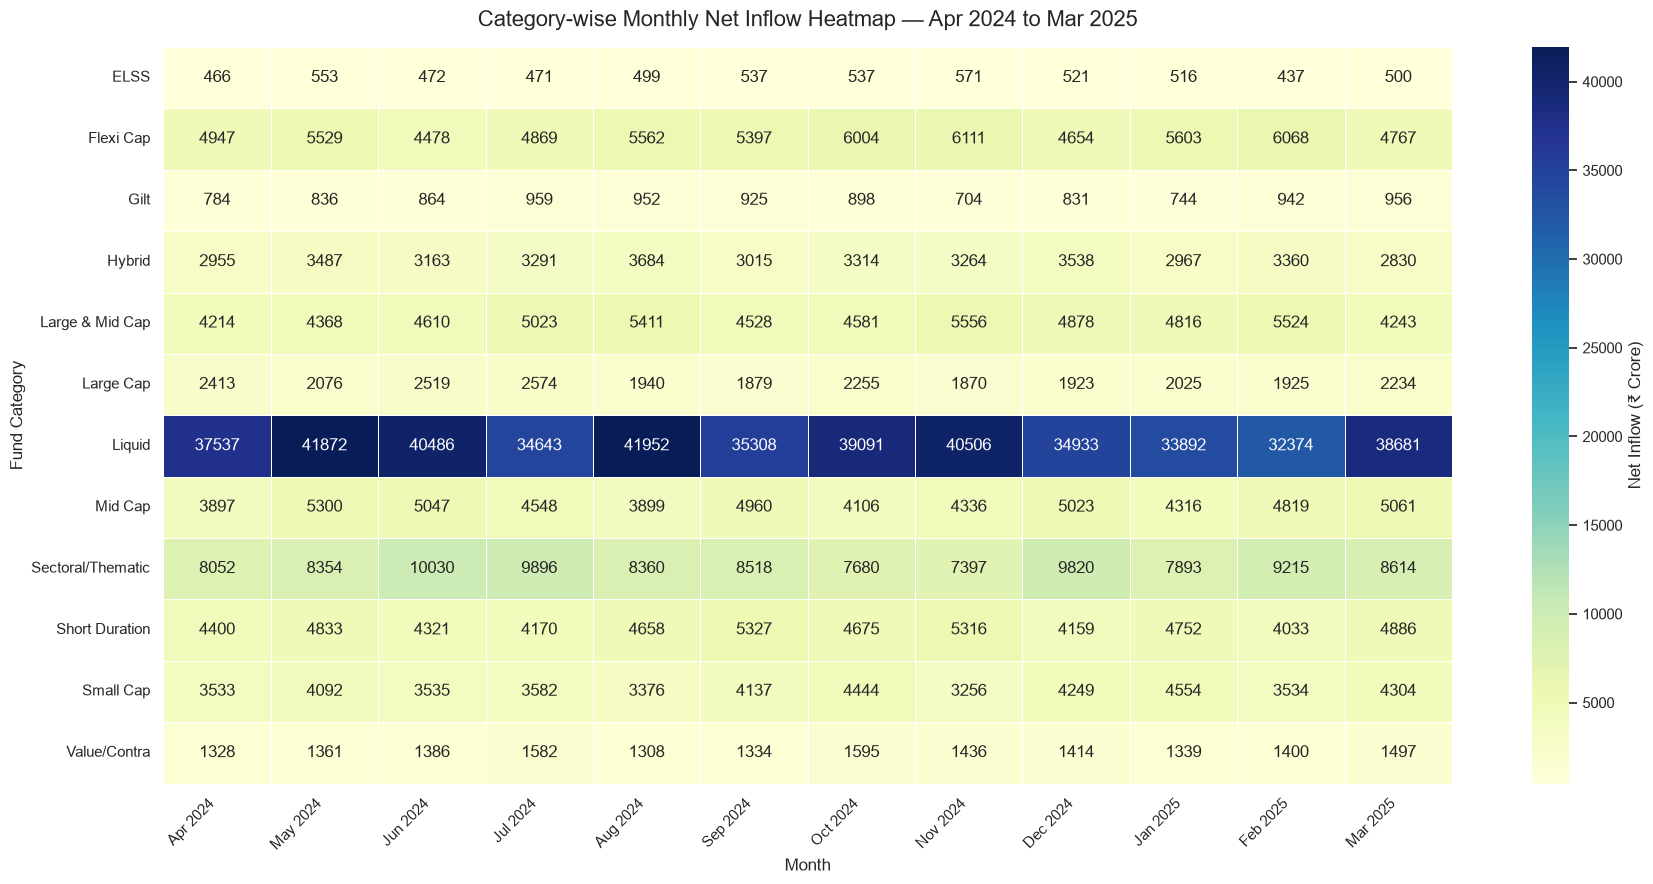


CATEGORY INFLOW HEATMAP
Rows (categories): 12
Columns (months): 12
Total net inflow: ₹932,239 Cr
Highest category-month inflow: ₹41,952 Cr
Highest category: Liquid
Highest month: August 2024

Saved: c:\Users\DELL\OneDrive\Desktop\MutualFundAnalytics\reports\category_inflow_heatmap.png


In [12]:
# ============================================================
# REQUIREMENT 4 — CATEGORY INFLOW HEATMAP
# Step 2: Monthly category-wise net inflow heatmap
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Prepare the data
# ------------------------------------------------------------

category_inflow_df = category_inflow_df.copy()

category_inflow_df["month"] = pd.to_datetime(
    category_inflow_df["month"],
    errors="coerce"
)

# Create month labels for the X-axis
category_inflow_df["month_label"] = (
    category_inflow_df["month"]
    .dt.strftime("%b %Y")
)

# ------------------------------------------------------------
# 2. Create category × month matrix
# ------------------------------------------------------------

heatmap_data = category_inflow_df.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

# Sort months chronologically
heatmap_data = heatmap_data.sort_index(axis=1)

# ------------------------------------------------------------
# 3. Create readable month labels
# ------------------------------------------------------------

heatmap_data.columns = [
    date.strftime("%b %Y")
    for date in heatmap_data.columns
]

# ------------------------------------------------------------
# 4. Display the heatmap
# ------------------------------------------------------------

plt.figure(figsize=(18, 9))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    cbar_kws={
        "label": "Net Inflow (₹ Crore)"
    }
)

plt.title(
    "Category-wise Monthly Net Inflow Heatmap — Apr 2024 to Mar 2025",
    fontsize=16,
    pad=15
)

plt.xlabel("Month", fontsize=12)
plt.ylabel("Fund Category", fontsize=12)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

# ------------------------------------------------------------
# 5. Save report-ready PNG
# ------------------------------------------------------------

output_path = REPORTS_DIR / "category_inflow_heatmap.png"

plt.savefig(
    output_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nCATEGORY INFLOW HEATMAP")
print("=" * 60)
print("Rows (categories):", heatmap_data.shape[0])
print("Columns (months):", heatmap_data.shape[1])
print(
    "Total net inflow:",
    f"₹{category_inflow_df['net_inflow_crore'].sum():,.0f} Cr"
)
print(
    "Highest category-month inflow:",
    f"₹{category_inflow_df['net_inflow_crore'].max():,.0f} Cr"
)

max_row = category_inflow_df.loc[
    category_inflow_df["net_inflow_crore"].idxmax()
]

print(
    "Highest category:",
    max_row["category"]
)

print(
    "Highest month:",
    max_row["month"].strftime("%B %Y")
)

print(f"\nSaved: {output_path}")

In [13]:
# ============================================================
# REQUIREMENT 5 — INVESTOR DEMOGRAPHICS
# Step 1: Load and validate investor transaction data
# ============================================================

import pandas as pd

# Load cleaned investor transaction data
investor_df = pd.read_csv(
    PROJECT_DIR / "data" / "processed" / "investor_transactions_cleaned.csv"
)

# Convert transaction date
investor_df["transaction_date"] = pd.to_datetime(
    investor_df["transaction_date"],
    errors="coerce"
)

# ------------------------------------------------------------
# Basic dataset information
# ------------------------------------------------------------

print("INVESTOR DATA SHAPE:", investor_df.shape)

print(
    "DATE RANGE:",
    investor_df["transaction_date"].min().date(),
    "to",
    investor_df["transaction_date"].max().date()
)

print(
    "NUMBER OF INVESTORS:",
    investor_df["investor_id"].nunique()
)

print(
    "NUMBER OF AGE GROUPS:",
    investor_df["age_group"].nunique()
)

print(
    "NUMBER OF GENDERS:",
    investor_df["gender"].nunique()
)

# ------------------------------------------------------------
# Required columns
# ------------------------------------------------------------

print("\nREQUIRED COLUMNS:")
print(
    [
        "investor_id",
        "amount_inr",
        "age_group",
        "gender"
    ]
)

print("\nMISSING VALUES:")
print(
    investor_df[
        [
            "investor_id",
            "amount_inr",
            "age_group",
            "gender"
        ]
    ].isna().sum()
)

# ------------------------------------------------------------
# Age groups
# ------------------------------------------------------------

print("\nAGE GROUPS:")
print(
    investor_df["age_group"]
    .value_counts(dropna=False)
    .sort_index()
)

# ------------------------------------------------------------
# Gender distribution
# ------------------------------------------------------------

print("\nGENDER DISTRIBUTION:")
print(
    investor_df["gender"]
    .value_counts(dropna=False)
)

# ------------------------------------------------------------
# SIP transactions
# ------------------------------------------------------------

sip_df_demo = investor_df[
    investor_df["transaction_type"]
    .astype(str)
    .str.upper()
    .eq("SIP")
].copy()

print("\nSIP TRANSACTIONS:", len(sip_df_demo))

print(
    "SIP AMOUNT RANGE:",
    f"₹{sip_df_demo['amount_inr'].min():,.2f}",
    "to",
    f"₹{sip_df_demo['amount_inr'].max():,.2f}"
)

print("\nSAMPLE INVESTOR DATA:")
print(
    investor_df[
        [
            "investor_id",
            "transaction_date",
            "transaction_type",
            "amount_inr",
            "age_group",
            "gender"
        ]
    ]
    .head(10)
    .to_string(index=False)
)

INVESTOR DATA SHAPE: (32778, 13)
DATE RANGE: 2024-01-01 to 2025-05-30
NUMBER OF INVESTORS: 5000
NUMBER OF AGE GROUPS: 5
NUMBER OF GENDERS: 2

REQUIRED COLUMNS:
['investor_id', 'amount_inr', 'age_group', 'gender']

MISSING VALUES:
investor_id    0
amount_inr     0
age_group      0
gender         0
dtype: int64

AGE GROUPS:
age_group
18-25     4916
26-35    13463
36-45     8146
46-55     3779
56+       2474
Name: count, dtype: int64

GENDER DISTRIBUTION:
gender
Male      21809
Female    10969
Name: count, dtype: int64

SIP TRANSACTIONS: 19716
SIP AMOUNT RANGE: ₹400.00 to ₹59,998.00

SAMPLE INVESTOR DATA:
investor_id transaction_date transaction_type  amount_inr age_group gender
  INV003054       2024-01-01              SIP        1834       56+ Female
  INV002952       2024-01-01       Redemption      392882     18-25   Male
  INV003420       2024-01-01              SIP         912     36-45   Male
  INV003436       2024-01-01              SIP        1102     36-45 Female
  INV004691    

AGE GROUP DISTRIBUTION
           Investors  Percentage
age_group                       
18-25           4916       15.00
26-35          13463       41.07
36-45           8146       24.85
46-55           3779       11.53
56+             2474        7.55


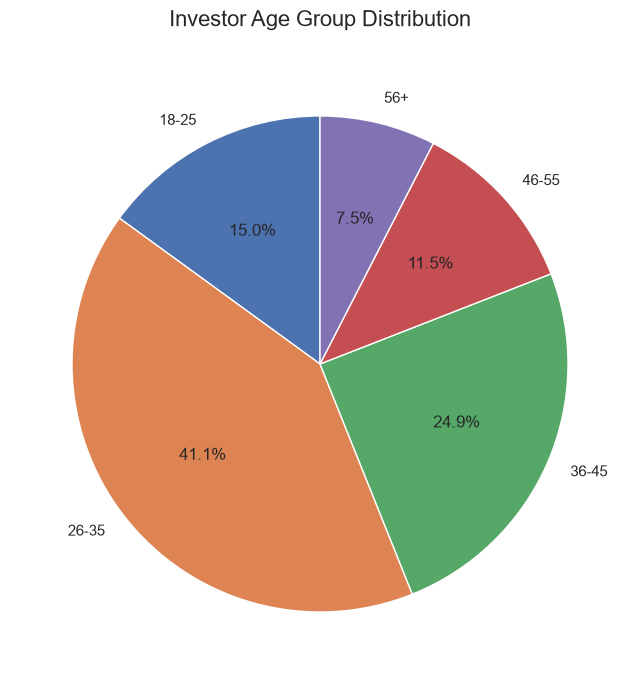


AGE GROUP PIE CHART
Largest age group: 26-35
Largest age group investors: 13463
Largest age group percentage: 41.07%
Saved: c:\Users\DELL\OneDrive\Desktop\MutualFundAnalytics\reports\investor_age_group_distribution.png


In [14]:
# ============================================================
# REQUIREMENT 5 — INVESTOR DEMOGRAPHICS
# Step 2: Age Group Distribution Pie Chart
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# 1. Prepare age-group data
# ------------------------------------------------------------

age_counts = (
    investor_df["age_group"]
    .value_counts()
    .reindex(["18-25", "26-35", "36-45", "46-55", "56+"])
    .dropna()
)

age_percent = (
    age_counts / age_counts.sum() * 100
)

print("AGE GROUP DISTRIBUTION")
print("=" * 60)

age_summary = pd.DataFrame({
    "Investors": age_counts.astype(int),
    "Percentage": age_percent.round(2)
})

print(age_summary)

# ------------------------------------------------------------
# 2. Create pie chart
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 7))

ax.pie(
    age_counts.values,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

ax.set_title(
    "Investor Age Group Distribution",
    fontsize=16,
    pad=20
)

plt.tight_layout()

# ------------------------------------------------------------
# 3. Save report-ready PNG
# ------------------------------------------------------------

REPORTS_DIR = PROJECT_DIR / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

output_path = REPORTS_DIR / "investor_age_group_distribution.png"

fig.savefig(
    output_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nAGE GROUP PIE CHART")
print("=" * 60)
print("Largest age group:", age_counts.idxmax())
print("Largest age group investors:", int(age_counts.max()))
print(
    "Largest age group percentage:",
    f"{age_percent.loc[age_counts.idxmax()]:.2f}%"
)
print("Saved:", output_path)

SIP AMOUNT BOXPLOT DATA
Total SIP transactions: 19716
Age groups: 5
Missing SIP amounts: 0
Non-positive SIP amounts: 0

SIP TRANSACTIONS BY AGE GROUP
age_group
18-25    2949
26-35    8063
36-45    4926
46-55    2300
56+      1478
Name: count, dtype: int64

MEDIAN SIP AMOUNT BY AGE GROUP
18-25: ₹5,020.00
26-35: ₹5,070.00
36-45: ₹5,250.00
46-55: ₹5,136.00
56+: ₹5,420.50


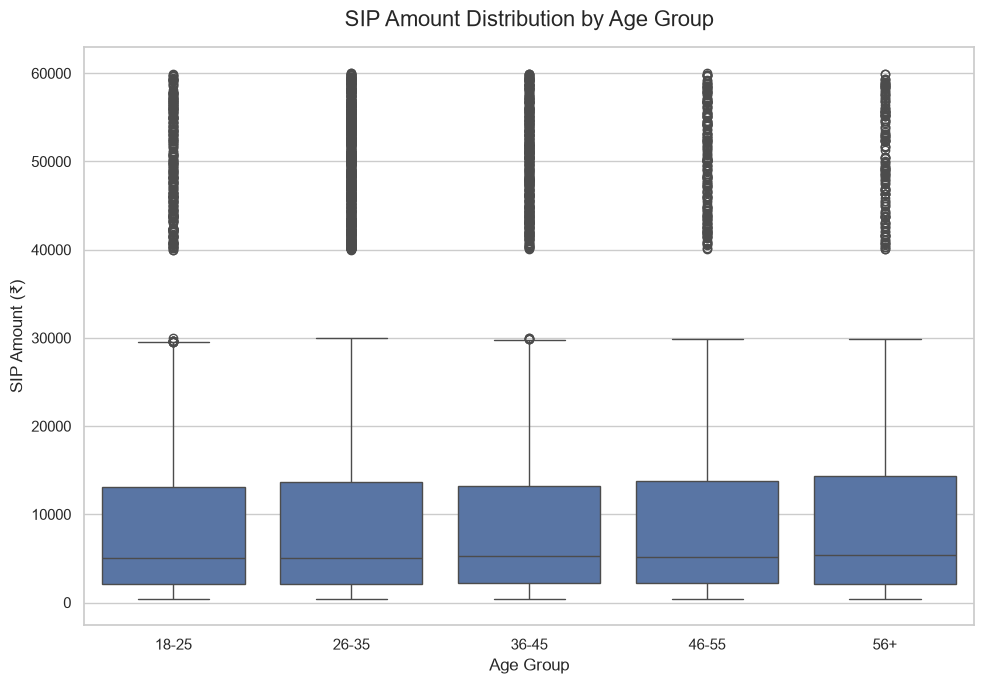


SIP AMOUNT BOXPLOT
Highest median SIP age group: 56+
Highest median SIP amount: ₹5,420.50
Saved: c:\Users\DELL\OneDrive\Desktop\MutualFundAnalytics\reports\sip_amount_boxplot_by_age_group.png


In [15]:
# ============================================================
# REQUIREMENT 5 — INVESTOR DEMOGRAPHICS
# Step 3: SIP Amount Box Plot by Age Group
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Prepare SIP transaction data
# ------------------------------------------------------------

sip_df = investor_df[
    investor_df["transaction_type"].astype(str).str.upper().eq("SIP")
].copy()

# Ensure amount is numeric
sip_df["amount_inr"] = pd.to_numeric(
    sip_df["amount_inr"],
    errors="coerce"
)

# Remove invalid amounts
sip_df = sip_df[
    sip_df["amount_inr"].notna() &
    (sip_df["amount_inr"] > 0)
].copy()

# Keep age groups in the required order
age_order = ["18-25", "26-35", "36-45", "46-55", "56+"]

sip_df["age_group"] = pd.Categorical(
    sip_df["age_group"],
    categories=age_order,
    ordered=True
)

# ------------------------------------------------------------
# 2. Validation
# ------------------------------------------------------------

print("SIP AMOUNT BOXPLOT DATA")
print("=" * 60)
print("Total SIP transactions:", len(sip_df))
print("Age groups:", sip_df["age_group"].nunique())
print("Missing SIP amounts:", sip_df["amount_inr"].isna().sum())
print("Non-positive SIP amounts:", (sip_df["amount_inr"] <= 0).sum())

print("\nSIP TRANSACTIONS BY AGE GROUP")
print("=" * 60)
print(
    sip_df["age_group"]
    .value_counts()
    .reindex(age_order)
    .fillna(0)
    .astype(int)
)

# ------------------------------------------------------------
# 3. Calculate median SIP amount by age group
# ------------------------------------------------------------

median_sip = (
    sip_df.groupby(
        "age_group",
        observed=False
    )["amount_inr"]
    .median()
    .reindex(age_order)
)

print("\nMEDIAN SIP AMOUNT BY AGE GROUP")
print("=" * 60)

for age_group, median_value in median_sip.items():
    print(
        f"{age_group}: ₹{median_value:,.2f}"
    )

# ------------------------------------------------------------
# 4. Create box plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

sns.boxplot(
    data=sip_df,
    x="age_group",
    y="amount_inr",
    order=age_order
)

plt.title(
    "SIP Amount Distribution by Age Group",
    fontsize=16,
    pad=15
)

plt.xlabel("Age Group", fontsize=12)
plt.ylabel("SIP Amount (₹)", fontsize=12)

plt.tight_layout()

# ------------------------------------------------------------
# 5. Save report-ready PNG
# ------------------------------------------------------------

REPORTS_DIR = PROJECT_DIR / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

output_path = (
    REPORTS_DIR /
    "sip_amount_boxplot_by_age_group.png"
)

plt.savefig(
    output_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 6. Print key insight
# ------------------------------------------------------------

highest_median_age = median_sip.idxmax()
highest_median_value = median_sip.max()

print("\nSIP AMOUNT BOXPLOT")
print("=" * 60)
print(
    "Highest median SIP age group:",
    highest_median_age
)
print(
    "Highest median SIP amount:",
    f"₹{highest_median_value:,.2f}"
)
print("Saved:", output_path)

GENDER DISTRIBUTION
        Investors  Percentage
gender                       
Male        21809       66.54
Female      10969       33.46


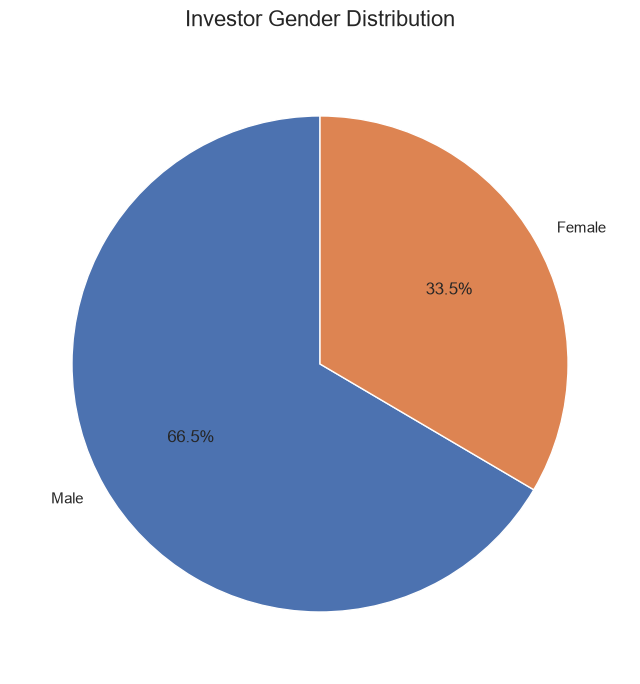


GENDER SPLIT
Largest gender group: Male
Number of investors/transactions: 21809
Percentage: 66.54%
Saved: c:\Users\DELL\OneDrive\Desktop\MutualFundAnalytics\reports\investor_gender_distribution.png


In [16]:
# ============================================================
# REQUIREMENT 5 — INVESTOR DEMOGRAPHICS
# Step 4: Gender Split
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Prepare gender data
# ------------------------------------------------------------

gender_counts = (
    investor_df["gender"]
    .astype(str)
    .str.strip()
    .str.title()
    .value_counts()
)

print("GENDER DISTRIBUTION")
print("=" * 60)

gender_percent = (
    gender_counts / gender_counts.sum() * 100
)

gender_summary = pd.DataFrame({
    "Investors": gender_counts.astype(int),
    "Percentage": gender_percent.round(2)
})

print(gender_summary)

# ------------------------------------------------------------
# 2. Create gender split pie chart
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 7))

ax.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

ax.set_title(
    "Investor Gender Distribution",
    fontsize=16,
    pad=20
)

plt.tight_layout()

# ------------------------------------------------------------
# 3. Save report-ready PNG
# ------------------------------------------------------------

REPORTS_DIR = PROJECT_DIR / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

output_path = (
    REPORTS_DIR /
    "investor_gender_distribution.png"
)

fig.savefig(
    output_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 4. Print key insight
# ------------------------------------------------------------

largest_gender = gender_counts.idxmax()
largest_gender_count = int(gender_counts.max())
largest_gender_percentage = float(
    gender_percent.loc[largest_gender]
)

print("\nGENDER SPLIT")
print("=" * 60)
print("Largest gender group:", largest_gender)
print("Number of investors/transactions:", largest_gender_count)
print(
    "Percentage:",
    f"{largest_gender_percentage:.2f}%"
)
print("Saved:", output_path)

In [17]:
# ============================================================
# REQUIREMENT 6 — GEOGRAPHIC DISTRIBUTION
# Step 1: Validate State and City-Tier Data
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Prepare geographic data
# ------------------------------------------------------------

geo_df = investor_df.copy()

geo_df["amount_inr"] = pd.to_numeric(
    geo_df["amount_inr"],
    errors="coerce"
)

geo_df["state"] = (
    geo_df["state"]
    .astype(str)
    .str.strip()
)

geo_df["city_tier"] = (
    geo_df["city_tier"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# ------------------------------------------------------------
# 2. Keep SIP transactions only
# ------------------------------------------------------------

geo_sip_df = geo_df[
    geo_df["transaction_type"]
    .astype(str)
    .str.upper()
    .eq("SIP")
].copy()

geo_sip_df = geo_sip_df[
    geo_sip_df["amount_inr"].notna() &
    (geo_sip_df["amount_inr"] > 0)
].copy()

# ------------------------------------------------------------
# 3. Validation
# ------------------------------------------------------------

print("GEOGRAPHIC DATA VALIDATION")
print("=" * 60)

print("Total SIP transactions:", len(geo_sip_df))
print("Number of states:", geo_sip_df["state"].nunique())
print("City tiers:", sorted(geo_sip_df["city_tier"].dropna().unique()))

print("\nMISSING VALUES")
print("=" * 60)
print(
    geo_sip_df[
        ["state", "city_tier", "amount_inr"]
    ].isna().sum()
)

print("\nSTATE SAMPLE")
print("=" * 60)
print(
    geo_sip_df["state"]
    .value_counts()
    .head(10)
)

print("\nCITY-TIER DISTRIBUTION")
print("=" * 60)
print(
    geo_sip_df["city_tier"]
    .value_counts()
)

# ------------------------------------------------------------
# 4. SIP amount by state
# ------------------------------------------------------------

state_sip = (
    geo_sip_df
    .groupby("state", as_index=False)["amount_inr"]
    .sum()
    .sort_values("amount_inr", ascending=False)
)

print("\nTOP STATES BY SIP AMOUNT")
print("=" * 60)

print(
    state_sip.head(10).to_string(index=False)
)

# ------------------------------------------------------------
# 5. T30 vs B30 validation
# ------------------------------------------------------------

tier_summary = (
    geo_sip_df
    .groupby("city_tier")["amount_inr"]
    .agg(["count", "sum"])
    .sort_values("sum", ascending=False)
)

print("\nT30 vs B30 SIP SUMMARY")
print("=" * 60)

print(tier_summary)

GEOGRAPHIC DATA VALIDATION
Total SIP transactions: 19716
Number of states: 12
City tiers: ['B30', 'T30']

MISSING VALUES
state         0
city_tier     0
amount_inr    0
dtype: int64

STATE SAMPLE
state
Madhya Pradesh    1796
Punjab            1792
Haryana           1690
Telangana         1656
Gujarat           1653
Tamil Nadu        1642
West Bengal       1638
Uttar Pradesh     1625
Karnataka         1620
Delhi             1606
Name: count, dtype: int64

CITY-TIER DISTRIBUTION
city_tier
T30    13123
B30     6593
Name: count, dtype: int64

TOP STATES BY SIP AMOUNT
         state  amount_inr
Madhya Pradesh    20682243
        Punjab    20140064
     Telangana    18620216
    Tamil Nadu    18404368
       Gujarat    18378904
       Haryana    18176696
     Karnataka    17696903
 Uttar Pradesh    17534858
   West Bengal    17495769
         Delhi    17113608

T30 vs B30 SIP SUMMARY
           count        sum
city_tier                  
T30        13123  144928621
B30         6593   723048

SIP AMOUNT BY STATE
         state  amount_inr  sip_amount_crore
Madhya Pradesh    20682243          2.068224
        Punjab    20140064          2.014006
     Telangana    18620216          1.862022
    Tamil Nadu    18404368          1.840437
       Gujarat    18378904          1.837890
       Haryana    18176696          1.817670
     Karnataka    17696903          1.769690
 Uttar Pradesh    17534858          1.753486
   West Bengal    17495769          1.749577
         Delhi    17113608          1.711361
     Rajasthan    16544233          1.654423
   Maharashtra    16445629          1.644563


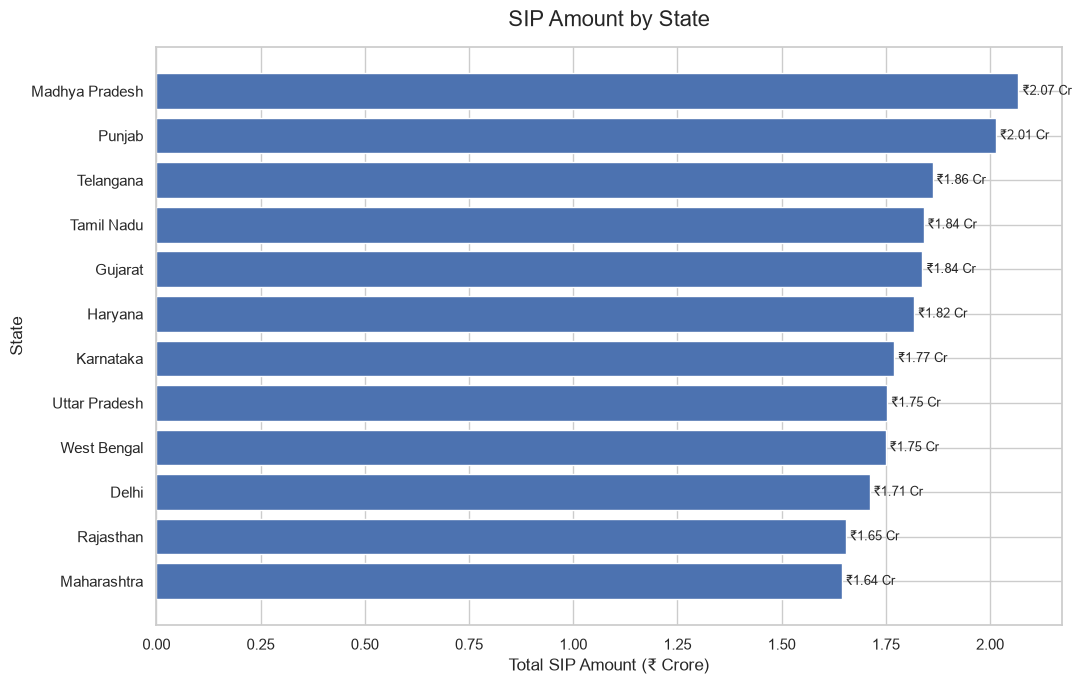


STATE SIP ANALYSIS
Highest SIP state: Madhya Pradesh
Highest SIP amount: ₹20,682,243
Highest SIP amount in crore: ₹2.07 Cr
Saved: c:\Users\DELL\OneDrive\Desktop\MutualFundAnalytics\reports\sip_amount_by_state.png


In [18]:
# ============================================================
# REQUIREMENT 6 — GEOGRAPHIC DISTRIBUTION
# Step 2: SIP Amount by State — Horizontal Bar Chart
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Prepare state-level SIP data
# ------------------------------------------------------------

state_sip = (
    geo_sip_df
    .groupby("state", as_index=False)["amount_inr"]
    .sum()
    .sort_values("amount_inr", ascending=True)
)

# Convert to crore for easier interpretation
state_sip["sip_amount_crore"] = (
    state_sip["amount_inr"] / 1e7
)

# ------------------------------------------------------------
# 2. Print complete state summary
# ------------------------------------------------------------

print("SIP AMOUNT BY STATE")
print("=" * 70)

print(
    state_sip[
        ["state", "amount_inr", "sip_amount_crore"]
    ].sort_values(
        "amount_inr",
        ascending=False
    ).to_string(index=False)
)

# ------------------------------------------------------------
# 3. Create horizontal bar chart
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(
    state_sip["state"],
    state_sip["sip_amount_crore"]
)

ax.set_title(
    "SIP Amount by State",
    fontsize=16,
    pad=15
)

ax.set_xlabel(
    "Total SIP Amount (₹ Crore)",
    fontsize=12
)

ax.set_ylabel(
    "State",
    fontsize=12
)

# Add values at the end of each bar
for i, value in enumerate(
    state_sip["sip_amount_crore"]
):
    ax.text(
        value,
        i,
        f" ₹{value:,.2f} Cr",
        va="center",
        fontsize=9
    )

plt.tight_layout()

# ------------------------------------------------------------
# 4. Save report-ready PNG
# ------------------------------------------------------------

REPORTS_DIR = PROJECT_DIR / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

output_path = (
    REPORTS_DIR /
    "sip_amount_by_state.png"
)

fig.savefig(
    output_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 5. Key insight
# ------------------------------------------------------------

top_state = (
    state_sip
    .sort_values("amount_inr", ascending=False)
    .iloc[0]
)

print("\nSTATE SIP ANALYSIS")
print("=" * 70)
print("Highest SIP state:", top_state["state"])
print(
    "Highest SIP amount:",
    f"₹{top_state['amount_inr']:,.0f}"
)
print(
    "Highest SIP amount in crore:",
    f"₹{top_state['sip_amount_crore']:,.2f} Cr"
)
print("Saved:", output_path)

CITY-TIER SIP ANALYSIS
city_tier  transactions  transaction_percentage  total_sip_amount  sip_amount_crore  amount_percentage
      T30         13123               66.560154         144928621         14.492862          66.715597
      B30          6593               33.439846          72304870          7.230487          33.284403

DOMINANT CITY TIER
Highest number of SIP transactions: T30
Transactions: 13123
Transaction percentage: 66.56%
Highest SIP amount tier: T30
Total SIP amount: ₹144,928,621
SIP amount in crore: ₹14.49 Cr


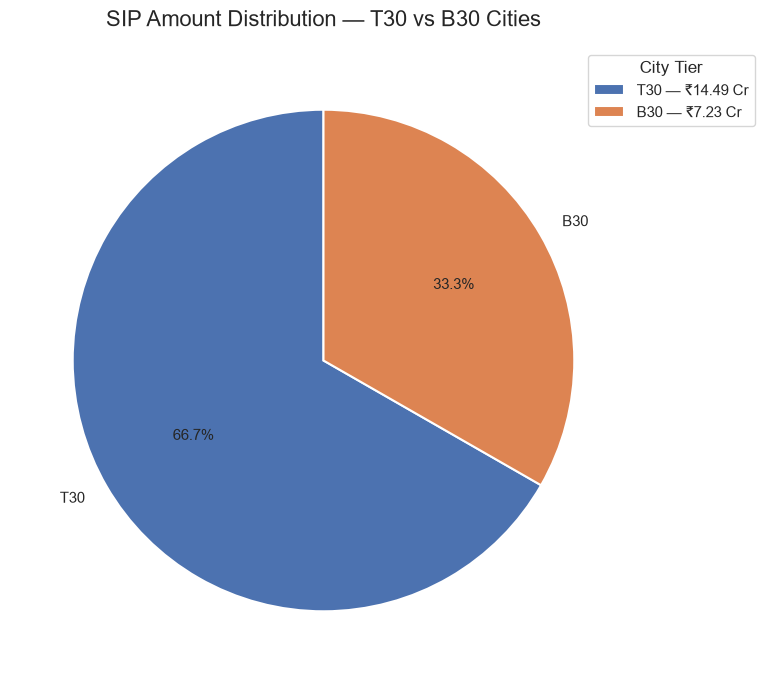


CITY-TIER PIE CHART
Total SIP transactions: 19716
Total SIP amount: ₹217,233,491
Number of city tiers: 2
Dominant transaction tier: T30
Dominant amount tier: T30
Saved: c:\Users\DELL\OneDrive\Desktop\MutualFundAnalytics\reports\sip_amount_t30_vs_b30.png


In [19]:
# ============================================================
# REQUIREMENT 6 — GEOGRAPHIC DISTRIBUTION
# Step 3: T30 vs B30 City-Tier Distribution
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. Prepare city-tier SIP data
# ============================================================

tier_sip = (
    geo_sip_df
    .groupby("city_tier", as_index=False)
    .agg(
        transactions=("amount_inr", "count"),
        total_sip_amount=("amount_inr", "sum")
    )
)

# Calculate percentage of transactions
tier_sip["transaction_percentage"] = (
    tier_sip["transactions"]
    / tier_sip["transactions"].sum()
    * 100
)

# Calculate percentage of SIP amount
tier_sip["amount_percentage"] = (
    tier_sip["total_sip_amount"]
    / tier_sip["total_sip_amount"].sum()
    * 100
)

# Convert amount to crore
tier_sip["sip_amount_crore"] = (
    tier_sip["total_sip_amount"] / 1e7
)

# Keep logical order: T30 first, B30 second
tier_order = ["T30", "B30"]

tier_sip["tier_order"] = tier_sip["city_tier"].apply(
    lambda x: tier_order.index(x)
    if x in tier_order
    else len(tier_order)
)

tier_sip = (
    tier_sip
    .sort_values("tier_order")
    .drop(columns="tier_order")
    .reset_index(drop=True)
)

# ============================================================
# 2. Print validation summary
# ============================================================

print("CITY-TIER SIP ANALYSIS")
print("=" * 70)

print(
    tier_sip[
        [
            "city_tier",
            "transactions",
            "transaction_percentage",
            "total_sip_amount",
            "sip_amount_crore",
            "amount_percentage"
        ]
    ].to_string(index=False)
)

# ============================================================
# 3. Identify dominant city tier
# ============================================================

top_transaction_tier = tier_sip.loc[
    tier_sip["transactions"].idxmax()
]

top_amount_tier = tier_sip.loc[
    tier_sip["total_sip_amount"].idxmax()
]

print("\nDOMINANT CITY TIER")
print("=" * 70)

print(
    "Highest number of SIP transactions:",
    top_transaction_tier["city_tier"]
)

print(
    "Transactions:",
    int(top_transaction_tier["transactions"])
)

print(
    "Transaction percentage:",
    f"{top_transaction_tier['transaction_percentage']:.2f}%"
)

print(
    "Highest SIP amount tier:",
    top_amount_tier["city_tier"]
)

print(
    "Total SIP amount:",
    f"₹{top_amount_tier['total_sip_amount']:,.0f}"
)

print(
    "SIP amount in crore:",
    f"₹{top_amount_tier['sip_amount_crore']:,.2f} Cr"
)

# ============================================================
# 4. Create T30 vs B30 pie chart
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))

wedges, texts, autotexts = ax.pie(
    tier_sip["total_sip_amount"],
    labels=tier_sip["city_tier"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"fontsize": 11}
)

ax.set_title(
    "SIP Amount Distribution — T30 vs B30 Cities",
    fontsize=16,
    pad=15
)

# ============================================================
# 5. Add amount information to legend
# ============================================================

legend_labels = []

for _, row in tier_sip.iterrows():
    legend_labels.append(
        f"{row['city_tier']} — "
        f"₹{row['sip_amount_crore']:,.2f} Cr"
    )

ax.legend(
    wedges,
    legend_labels,
    title="City Tier",
    loc="upper right",
    bbox_to_anchor=(1.20, 1.00)
)

plt.tight_layout()

# ============================================================
# 6. Save report-ready PNG
# ============================================================

REPORTS_DIR = PROJECT_DIR / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

output_path = (
    REPORTS_DIR /
    "sip_amount_t30_vs_b30.png"
)

fig.savefig(
    output_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 7. Final validation
# ============================================================

print("\nCITY-TIER PIE CHART")
print("=" * 70)

print(
    "Total SIP transactions:",
    int(tier_sip["transactions"].sum())
)

print(
    "Total SIP amount:",
    f"₹{tier_sip['total_sip_amount'].sum():,.0f}"
)

print(
    "Number of city tiers:",
    tier_sip["city_tier"].nunique()
)

print(
    "Dominant transaction tier:",
    top_transaction_tier["city_tier"]
)

print(
    "Dominant amount tier:",
    top_amount_tier["city_tier"]
)

print("Saved:", output_path)

In [22]:
# ============================================================
# REQUIREMENT 7 — FOLIO COUNT GROWTH
# Line chart: Jan 2022 to Dec 2025
# ============================================================

import pandas as pd
import plotly.graph_objects as go
from pathlib import Path

# ============================================================
# 1. FIND FOLIO CSV AUTOMATICALLY
# ============================================================

FILE_NAME = "06_industry_folio_count.csv"

current_dir = Path.cwd()

candidate_paths = [
    current_dir / FILE_NAME,
    current_dir / "data" / FILE_NAME,
    current_dir / "data" / "raw" / FILE_NAME,
    current_dir.parent / FILE_NAME,
    current_dir.parent / "data" / FILE_NAME,
    current_dir.parent / "data" / "raw" / FILE_NAME,
    current_dir.parent.parent / FILE_NAME,
    current_dir.parent.parent / "data" / FILE_NAME,
    current_dir.parent.parent / "data" / "raw" / FILE_NAME,
]

folio_path = None

for path in candidate_paths:
    if path.exists() and path.is_file():
        folio_path = path
        break

# Recursive search if not found above
if folio_path is None:

    project_root = None

    for parent in [current_dir] + list(current_dir.parents):
        if parent.name.lower() == "mutualfundanalytics":
            project_root = parent
            break

    if project_root is None:
        project_root = current_dir

    matches = list(project_root.rglob(FILE_NAME))

    if matches:
        folio_path = matches[0]

# ============================================================
# 2. VALIDATE FILE
# ============================================================

if folio_path is None:

    print("=" * 70)
    print("ERROR — FOLIO CSV NOT FOUND")
    print("=" * 70)
    print(f"Expected file: {FILE_NAME}")
    print(f"Current directory: {current_dir}")

else:

    print("=" * 70)
    print("REQUIREMENT 7 — FOLIO COUNT GROWTH")
    print("=" * 70)

    print(f"CSV found at: {folio_path}")

    # ========================================================
    # 3. LOAD DATA
    # ========================================================

    folio_df = pd.read_csv(folio_path)

    # ========================================================
    # 4. CHECK REQUIRED COLUMNS
    # ========================================================

    required_columns = [
        "month",
        "total_folios_crore"
    ]

    missing_columns = [
        col for col in required_columns
        if col not in folio_df.columns
    ]

    if missing_columns:

        print("\nERROR — REQUIRED COLUMNS MISSING")
        print("=" * 70)
        print("Missing columns:", missing_columns)
        print("Available columns:", list(folio_df.columns))

    else:

        # ====================================================
        # 5. CLEAN DATA
        # ====================================================

        folio_df["month"] = pd.to_datetime(
            folio_df["month"],
            errors="coerce"
        )

        folio_df["total_folios_crore"] = pd.to_numeric(
            folio_df["total_folios_crore"],
            errors="coerce"
        )

        folio_df = folio_df.dropna(
            subset=[
                "month",
                "total_folios_crore"
            ]
        ).copy()

        folio_df = folio_df.sort_values(
            "month"
        ).reset_index(drop=True)

        # ====================================================
        # 6. PROJECT DATE RANGE
        # ====================================================

        folio_df = folio_df[
            (folio_df["month"] >= pd.Timestamp("2022-01-01")) &
            (folio_df["month"] <= pd.Timestamp("2025-12-31"))
        ].copy()

        folio_df = folio_df.sort_values(
            "month"
        ).reset_index(drop=True)

        # ====================================================
        # 7. CREATE STRING DATE COLUMN
        #
        # IMPORTANT:
        # Plotly/Kaleido receives strings instead of pandas
        # Timestamp objects. This fixes the export error.
        # ====================================================

        folio_df["month_label"] = folio_df[
            "month"
        ].dt.strftime("%Y-%m-%d")

        folio_df["display_month"] = folio_df[
            "month"
        ].dt.strftime("%b %Y")

        # ====================================================
        # 8. VALIDATION OUTPUT
        # ====================================================

        print("\nFOLIO DATA VALIDATION")
        print("=" * 70)

        print(
            f"Data shape              : {folio_df.shape}"
        )

        print(
            f"Date range              : "
            f"{folio_df['month'].min():%Y-%m-%d} "
            f"to "
            f"{folio_df['month'].max():%Y-%m-%d}"
        )

        print(
            f"Missing month values   : "
            f"{folio_df['month'].isna().sum()}"
        )

        print(
            f"Missing folio values   : "
            f"{folio_df['total_folios_crore'].isna().sum()}"
        )

        # ====================================================
        # 9. START / END VALUES
        # ====================================================

        start_row = folio_df.iloc[0]
        end_row = folio_df.iloc[-1]

        start_value = float(
            start_row["total_folios_crore"]
        )

        end_value = float(
            end_row["total_folios_crore"]
        )

        absolute_growth = (
            end_value - start_value
        )

        overall_growth = (
            absolute_growth / start_value
        ) * 100

        # ====================================================
        # 10. KEY MILESTONES
        # ====================================================

        min_idx = (
            folio_df[
                "total_folios_crore"
            ].idxmin()
        )

        max_idx = (
            folio_df[
                "total_folios_crore"
            ].idxmax()
        )

        min_row = folio_df.loc[min_idx]
        max_row = folio_df.loc[max_idx]

        # ====================================================
        # 11. PRINT SUMMARY
        # ====================================================

        print("\nFOLIO GROWTH SUMMARY")
        print("=" * 70)

        print(
            f"Starting folios       : "
            f"{start_value:.2f} Cr"
        )

        print(
            f"Starting month        : "
            f"{start_row['month']:%B %Y}"
        )

        print(
            f"Ending folios         : "
            f"{end_value:.2f} Cr"
        )

        print(
            f"Ending month          : "
            f"{end_row['month']:%B %Y}"
        )

        print(
            f"Absolute increase     : "
            f"{absolute_growth:.2f} Cr"
        )

        print(
            f"Overall growth        : "
            f"{overall_growth:.2f}%"
        )

        print("\nKEY MILESTONES")
        print("=" * 70)

        print(
            f"Lowest folio count    : "
            f"{float(min_row['total_folios_crore']):.2f} Cr "
            f"({min_row['month']:%b %Y})"
        )

        print(
            f"Highest folio count   : "
            f"{float(max_row['total_folios_crore']):.2f} Cr "
            f"({max_row['month']:%b %Y})"
        )

        # ====================================================
        # 12. CREATE PLOTLY FIGURE
        # ====================================================

        fig = go.Figure()

        fig.add_trace(
            go.Scatter(
                x=folio_df["month_label"].astype(str).tolist(),
                y=folio_df[
                    "total_folios_crore"
                ].astype(float).tolist(),

                mode="lines+markers",

                name="Total Folios",

                line=dict(
                    width=3
                ),

                marker=dict(
                    size=7
                ),

                hovertemplate=(
                    "<b>%{x}</b><br>"
                    "Total Folios: %{y:.2f} Cr"
                    "<extra></extra>"
                )
            )
        )

        # ====================================================
        # 13. START MILESTONE
        # ====================================================

        fig.add_annotation(
            x=str(start_row["month_label"]),
            y=start_value,

            text=(
                f"Start<br>"
                f"{start_value:.2f} Cr"
            ),

            showarrow=True,
            arrowhead=2,

            ax=35,
            ay=-50
        )

        # ====================================================
        # 14. PEAK MILESTONE
        # ====================================================

        if max_idx != 0 and max_idx != len(folio_df) - 1:

            fig.add_annotation(
                x=str(max_row["month_label"]),
                y=float(
                    max_row["total_folios_crore"]
                ),

                text=(
                    f"Peak<br>"
                    f"{float(max_row['total_folios_crore']):.2f} Cr"
                ),

                showarrow=True,
                arrowhead=2,

                ax=0,
                ay=-55
            )

        # ====================================================
        # 15. END MILESTONE
        # ====================================================

        fig.add_annotation(
            x=str(end_row["month_label"]),
            y=end_value,

            text=(
                f"Dec 2025<br>"
                f"{end_value:.2f} Cr"
            ),

            showarrow=True,
            arrowhead=2,

            ax=-50,
            ay=-55
        )

        # ====================================================
        # 16. CHART LAYOUT
        # ====================================================

        fig.update_layout(

            title=dict(
                text=(
                    "Mutual Fund Folio Count Growth "
                    "— January 2022 to December 2025"
                ),
                x=0.5,
                xanchor="center"
            ),

            xaxis=dict(
                title="Month",
                showgrid=True,
                type="category",
                tickangle=0
            ),

            yaxis=dict(
                title="Total Folios (Crore)",
                showgrid=True,
                rangemode="tozero",
                tickformat=".2f"
            ),

            template="plotly_white",

            hovermode="x unified",

            width=1400,

            height=700,

            margin=dict(
                l=90,
                r=90,
                t=100,
                b=90
            ),

            font=dict(
                size=13
            )
        )

        # ====================================================
        # 17. DISPLAY CHART
        # ====================================================

        fig.show()

        # ====================================================
        # 18. FIND PROJECT ROOT
        # ====================================================

        project_root = None

        for parent in [folio_path.parent] + list(
            folio_path.parents
        ):
            if parent.name.lower() == "mutualfundanalytics":
                project_root = parent
                break

        if project_root is None:
            project_root = current_dir

        # ====================================================
        # 19. CREATE REPORTS DIRECTORY
        # ====================================================

        reports_dir = (
            project_root / "reports"
        )

        reports_dir.mkdir(
            parents=True,
            exist_ok=True
        )

        # ====================================================
        # 20. OUTPUT FILE
        # ====================================================

        output_path = (
            reports_dir /
            "folio_count_growth.png"
        )

        # ====================================================
        # 21. EXPORT PNG
        # ====================================================

        try:

            fig.write_image(
                str(output_path),
                width=1400,
                height=700,
                scale=2
            )

            print("\n" + "=" * 70)
            print("FOLIO COUNT GROWTH — COMPLETE")
            print("=" * 70)

            print(
                f"Chart saved successfully:\n"
                f"{output_path}"
            )

        except Exception as e:

            print("\n" + "=" * 70)
            print("PNG EXPORT ERROR")
            print("=" * 70)

            print(
                f"{type(e).__name__}: {e}"
            )

        # ====================================================
        # 22. FINAL VERIFICATION
        # ====================================================

        print("\nFINAL REQUIREMENT 7 RESULTS")
        print("=" * 70)

        print(
            f"Jan 2022 folios       : "
            f"{start_value:.2f} Cr"
        )

        print(
            f"Dec 2025 folios       : "
            f"{end_value:.2f} Cr"
        )

        print(
            f"Absolute increase     : "
            f"{absolute_growth:.2f} Cr"
        )

        print(
            f"Overall growth        : "
            f"{overall_growth:.2f}%"
        )

        print(
            f"Peak folios           : "
            f"{float(max_row['total_folios_crore']):.2f} Cr"
        )

        print(
            f"Peak month            : "
            f"{max_row['month']:%B %Y}"
        )

        print("=" * 70)

REQUIREMENT 7 — FOLIO COUNT GROWTH
CSV found at: c:\Users\DELL\OneDrive\Desktop\MutualFundAnalytics\data\raw\06_industry_folio_count.csv

FOLIO DATA VALIDATION
Data shape              : (21, 8)
Date range              : 2022-01-01 to 2025-12-01
Missing month values   : 0
Missing folio values   : 0

FOLIO GROWTH SUMMARY
Starting folios       : 13.26 Cr
Starting month        : January 2022
Ending folios         : 26.12 Cr
Ending month          : December 2025
Absolute increase     : 12.86 Cr
Overall growth        : 96.98%

KEY MILESTONES
Lowest folio count    : 13.26 Cr (Jan 2022)
Highest folio count   : 26.12 Cr (Dec 2025)



FOLIO COUNT GROWTH — COMPLETE
Chart saved successfully:
c:\Users\DELL\OneDrive\Desktop\MutualFundAnalytics\reports\folio_count_growth.png

FINAL REQUIREMENT 7 RESULTS
Jan 2022 folios       : 13.26 Cr
Dec 2025 folios       : 26.12 Cr
Absolute increase     : 12.86 Cr
Overall growth        : 96.98%
Peak folios           : 26.12 Cr
Peak month            : December 2025


REQUIREMENT 8 — NAV RETURN CORRELATION MATRIX
NAV source: existing nav_df dataframe

NAV COLUMN DETECTION
Date column       : date
NAV column        : nav
Fund identifier   : amfi_code

NAV DATA VALIDATION
Total NAV rows       : 46,000
Unique funds         : 40
Date range           : 2022-01-03 to 2026-05-29

SELECTED FUNDS
 1. 100016
 2. 100025
 3. 100033
 4. 101206
 5. 101207
 6. 101208
 7. 102885
 8. 102886
 9. 102887
10. 118632

CORRELATION MATRIX
amfi_code  100016  100025  100033  101206  101207  101208  102885  102886  102887  118632
amfi_code                                                                                
100016       1.00    0.05   -0.00    0.03    0.02   -0.03   -0.09   -0.01   -0.02   -0.03
100025       0.05    1.00    0.00    0.02   -0.01    0.02   -0.00    0.01   -0.01   -0.01
100033      -0.00    0.00    1.00   -0.02    0.00    0.01   -0.03   -0.02   -0.04   -0.01
101206       0.03    0.02   -0.02    1.00    0.01   -0.03    0.00    0.01   -0.01   -0.01
1012

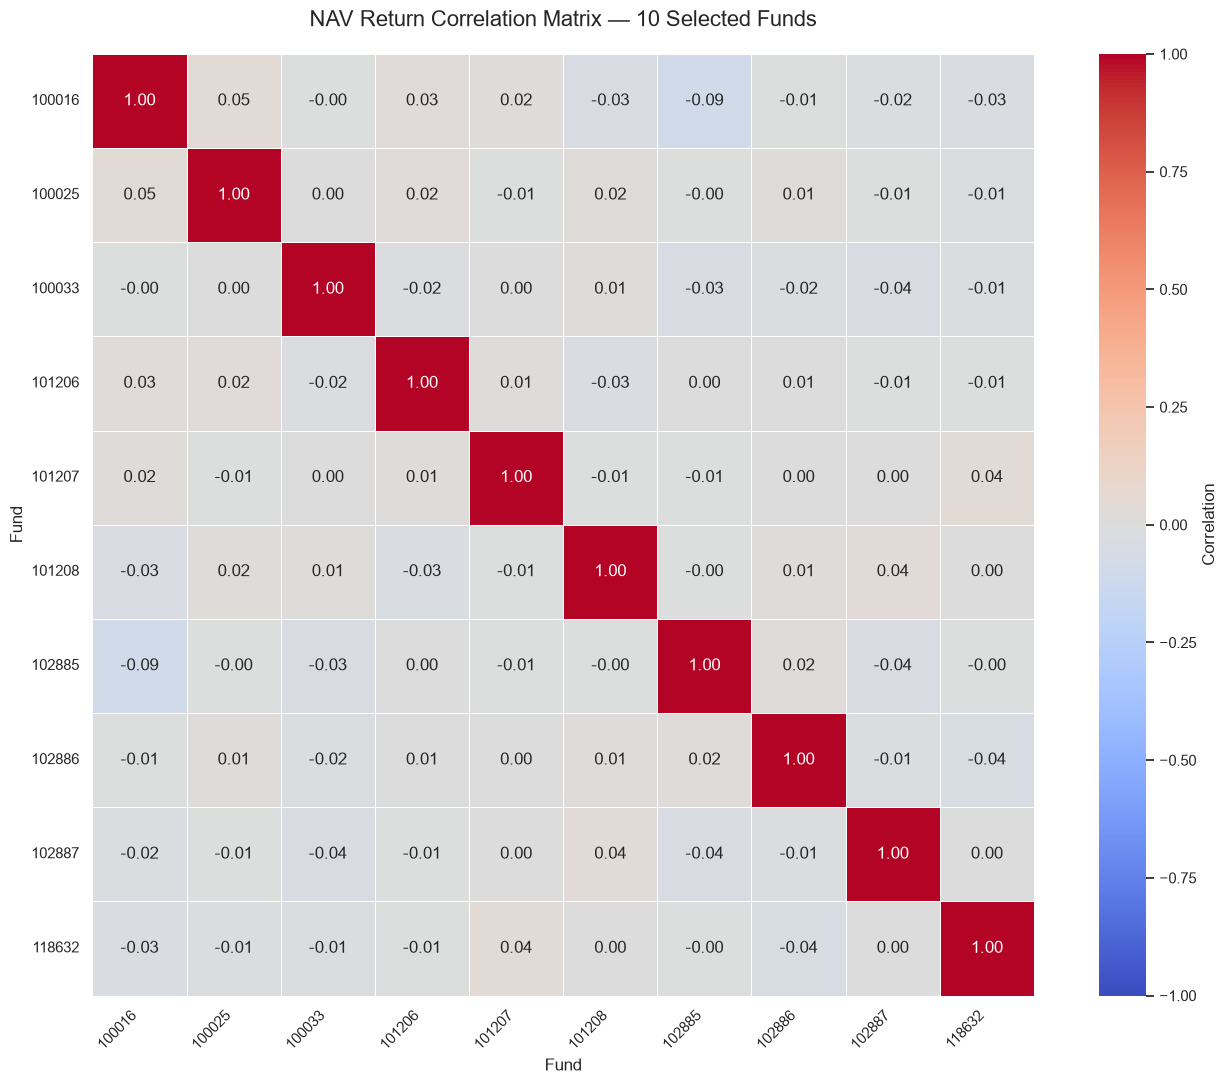


FINAL REQUIREMENT 8 VALIDATION
Selected funds       : 10
Valid correlation funds: 10
Daily return rows    : 1,150
Correlation range    : -0.0935 to 1.0000
Output file          : c:\Users\DELL\OneDrive\Desktop\MutualFundAnalytics\reports\nav_return_correlation_matrix.png


In [23]:
# ============================================================
# REQUIREMENT 8 — NAV RETURN CORRELATION MATRIX
# 10 SELECTED FUNDS — DAILY RETURNS
# ============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 1. LOCATE PROJECT ROOT
# ============================================================

current_dir = Path.cwd()

project_root = None

for parent in [current_dir] + list(current_dir.parents):
    if parent.name.lower() == "mutualfundanalytics":
        project_root = parent
        break

if project_root is None:
    project_root = current_dir

# ============================================================
# 2. FIND NAV DATA
# ============================================================

# First try existing dataframe from earlier notebook cells.
nav_source = None

if "nav_df" in globals() and isinstance(nav_df, pd.DataFrame):
    nav_source = nav_df.copy()
    nav_source_name = "existing nav_df dataframe"

else:

    # Search project CSV files for NAV-related files
    csv_files = list(
        (project_root / "data").rglob("*.csv")
    ) if (project_root / "data").exists() else []

    nav_candidates = []

    for csv_file in csv_files:

        name = csv_file.name.lower()

        if (
            "nav" in name
            or "scheme" in name
            or "mutual" in name
        ):
            nav_candidates.append(csv_file)

    # Try files until one contains NAV-like columns
    for csv_file in nav_candidates:

        try:

            temp_df = pd.read_csv(
                csv_file,
                nrows=5
            )

            cols_lower = [
                str(c).lower()
                for c in temp_df.columns
            ]

            has_date = any(
                c in cols_lower
                for c in [
                    "date",
                    "nav_date",
                    "valuation_date"
                ]
            )

            has_nav = any(
                "nav" in c
                for c in cols_lower
            )

            if has_date and has_nav:

                nav_source = pd.read_csv(
                    csv_file
                )

                nav_source_name = str(
                    csv_file
                )

                break

        except Exception:
            continue


# ============================================================
# 3. VALIDATE NAV DATA
# ============================================================

if nav_source is None:

    print("=" * 70)
    print("ERROR — NAV DATA NOT FOUND")
    print("=" * 70)
    print(
        "No existing nav_df dataframe or suitable NAV CSV "
        "was found inside the project."
    )

else:

    print("=" * 70)
    print("REQUIREMENT 8 — NAV RETURN CORRELATION MATRIX")
    print("=" * 70)

    print(
        f"NAV source: {nav_source_name}"
    )

    # Work on a copy
    nav_data = nav_source.copy()

    # ========================================================
    # 4. IDENTIFY COLUMN NAMES
    # ========================================================

    original_columns = list(
        nav_data.columns
    )

    lower_to_original = {
        str(col).strip().lower(): col
        for col in nav_data.columns
    }

    # --------------------------------------------------------
    # Date column
    # --------------------------------------------------------

    date_candidates = [
        "date",
        "nav_date",
        "valuation_date",
        "as_on_date"
    ]

    date_col = None

    for candidate in date_candidates:

        if candidate in lower_to_original:
            date_col = lower_to_original[candidate]
            break

    # Fallback: find a column containing "date"
    if date_col is None:

        for col in nav_data.columns:

            if "date" in str(col).lower():

                date_col = col
                break

    # --------------------------------------------------------
    # NAV column
    # --------------------------------------------------------

    nav_candidates = [
        "nav",
        "nav_value",
        "net_asset_value"
    ]

    nav_col = None

    for candidate in nav_candidates:

        if candidate in lower_to_original:
            nav_col = lower_to_original[candidate]
            break

    # Fallback: first column containing NAV
    if nav_col is None:

        for col in nav_data.columns:

            if "nav" in str(col).lower():

                nav_col = col
                break

    # --------------------------------------------------------
    # Fund identifier column
    # --------------------------------------------------------

    fund_candidates = [
        "amfi_code",
        "scheme_code",
        "fund_code",
        "scheme",
        "scheme_name",
        "fund_name",
        "fund_house"
    ]

    fund_col = None

    for candidate in fund_candidates:

        if candidate in lower_to_original:
            fund_col = lower_to_original[candidate]
            break

    # Fallback: identify likely fund/code column
    if fund_col is None:

        for col in nav_data.columns:

            col_lower = str(col).lower()

            if (
                "scheme" in col_lower
                or "fund" in col_lower
                or "amfi" in col_lower
                or "code" in col_lower
            ):

                fund_col = col
                break

    # ========================================================
    # 5. COLUMN VALIDATION
    # ========================================================

    print("\nNAV COLUMN DETECTION")
    print("=" * 70)

    print(
        f"Date column       : {date_col}"
    )

    print(
        f"NAV column        : {nav_col}"
    )

    print(
        f"Fund identifier   : {fund_col}"
    )

    if (
        date_col is None
        or nav_col is None
        or fund_col is None
    ):

        print("\nERROR — Could not identify required NAV columns.")

        print(
            "\nAvailable columns:"
        )

        print(original_columns)

    else:

        # ====================================================
        # 6. CLEAN NAV DATA
        # ====================================================

        nav_data[date_col] = pd.to_datetime(
            nav_data[date_col],
            errors="coerce"
        )

        nav_data[nav_col] = pd.to_numeric(
            nav_data[nav_col],
            errors="coerce"
        )

        nav_data[fund_col] = (
            nav_data[fund_col]
            .astype(str)
            .str.strip()
        )

        nav_data = nav_data.dropna(
            subset=[
                date_col,
                nav_col,
                fund_col
            ]
        ).copy()

        # Remove invalid/non-positive NAVs
        nav_data = nav_data[
            nav_data[nav_col] > 0
        ].copy()

        nav_data = nav_data.sort_values(
            [fund_col, date_col]
        ).reset_index(drop=True)

        # ====================================================
        # 7. DATA VALIDATION
        # ====================================================

        print("\nNAV DATA VALIDATION")
        print("=" * 70)

        print(
            f"Total NAV rows       : {len(nav_data):,}"
        )

        print(
            f"Unique funds         : "
            f"{nav_data[fund_col].nunique():,}"
        )

        print(
            f"Date range           : "
            f"{nav_data[date_col].min():%Y-%m-%d} "
            f"to "
            f"{nav_data[date_col].max():%Y-%m-%d}"
        )

        # ====================================================
        # 8. SELECT 10 FUNDS
        #
        # Select the 10 funds/schemes having the greatest
        # number of valid NAV observations.
        # This ensures a stable correlation calculation.
        # ====================================================

        fund_counts = (
            nav_data
            .groupby(fund_col)[date_col]
            .nunique()
            .sort_values(
                ascending=False
            )
        )

        selected_funds = (
            fund_counts
            .head(10)
            .index
            .tolist()
        )

        nav_selected = nav_data[
            nav_data[fund_col].isin(
                selected_funds
            )
        ].copy()

        print("\nSELECTED FUNDS")
        print("=" * 70)

        for i, fund in enumerate(
            selected_funds,
            start=1
        ):

            print(
                f"{i:2d}. {fund}"
            )

        # ====================================================
        # 9. CREATE NAV MATRIX
        # ====================================================

        nav_matrix = (
            nav_selected
            .pivot_table(
                index=date_col,
                columns=fund_col,
                values=nav_col,
                aggfunc="last"
            )
            .sort_index()
        )

        # ====================================================
        # 10. CALCULATE DAILY RETURNS
        # ====================================================

        daily_returns = (
            nav_matrix
            .pct_change()
            .replace(
                [np.inf, -np.inf],
                np.nan
            )
        )

        # ====================================================
        # 11. CORRELATION MATRIX
        # ====================================================

        correlation_matrix = (
            daily_returns
            .corr(
                min_periods=30
            )
        )

        # ====================================================
        # 12. REMOVE FUNDS WITH INSUFFICIENT DATA
        # ====================================================

        valid_funds = [
            fund
            for fund in correlation_matrix.columns
            if correlation_matrix[fund]
            .notna()
            .sum() >= 2
        ]

        correlation_matrix = (
            correlation_matrix
            .loc[
                valid_funds,
                valid_funds
            ]
        )

        # ====================================================
        # 13. ROUND FOR DISPLAY
        # ====================================================

        correlation_display = (
            correlation_matrix
            .round(2)
        )

        print("\nCORRELATION MATRIX")
        print("=" * 70)

        print(
            correlation_display
        )

        # ====================================================
        # 14. FIND STRONGEST CORRELATIONS
        # ====================================================

        upper_triangle = (
            correlation_matrix
            .where(
                np.triu(
                    np.ones(
                        correlation_matrix.shape
                    ),
                    k=1
                ).astype(bool)
            )
        )

        correlation_pairs = (
            upper_triangle
            .stack()
            .sort_values(
                ascending=False
            )
        )

        print("\nSTRONGEST POSITIVE CORRELATIONS")
        print("=" * 70)

        if len(correlation_pairs) > 0:

            for pair, value in (
                correlation_pairs
                .head(5)
                .items()
            ):

                print(
                    f"{pair[0]} ↔ {pair[1]} : "
                    f"{value:.4f}"
                )

        print("\nSTRONGEST NEGATIVE CORRELATIONS")
        print("=" * 70)

        negative_pairs = (
            correlation_pairs
            .sort_values(
                ascending=True
            )
        )

        if len(negative_pairs) > 0:

            for pair, value in (
                negative_pairs
                .head(5)
                .items()
            ):

                print(
                    f"{pair[0]} ↔ {pair[1]} : "
                    f"{value:.4f}"
                )

        # ====================================================
        # 15. SEABORN HEATMAP
        # ====================================================

        plt.figure(
            figsize=(14, 11)
        )

        sns.heatmap(
            correlation_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
            center=0,
            linewidths=0.5,
            square=True,
            cbar_kws={
                "label": "Correlation"
            }
        )

        plt.title(
            "NAV Return Correlation Matrix — 10 Selected Funds",
            fontsize=16,
            pad=20
        )

        plt.xlabel(
            "Fund"
        )

        plt.ylabel(
            "Fund"
        )

        plt.xticks(
            rotation=45,
            ha="right"
        )

        plt.yticks(
            rotation=0
        )

        plt.tight_layout()

        # ====================================================
        # 16. SAVE REPORT-READY PNG
        # ====================================================

        reports_dir = (
            project_root / "reports"
        )

        reports_dir.mkdir(
            parents=True,
            exist_ok=True
        )

        output_path = (
            reports_dir /
            "nav_return_correlation_matrix.png"
        )

        try:

            plt.savefig(
                output_path,
                dpi=200,
                bbox_inches="tight"
            )

            print("\n" + "=" * 70)
            print("NAV CORRELATION MATRIX — COMPLETE")
            print("=" * 70)

            print(
                f"Number of funds: "
                f"{len(correlation_matrix)}"
            )

            print(
                f"Chart saved successfully:"
            )

            print(
                output_path
            )

        except Exception as e:

            print("\nPNG EXPORT ERROR")
            print(
                f"{type(e).__name__}: {e}"
            )

        # ====================================================
        # 17. DISPLAY
        # ====================================================

        plt.show()

        # ====================================================
        # 18. FINAL VALIDATION
        # ====================================================

        print("\nFINAL REQUIREMENT 8 VALIDATION")
        print("=" * 70)

        print(
            f"Selected funds       : "
            f"{len(selected_funds)}"
        )

        print(
            f"Valid correlation funds: "
            f"{len(correlation_matrix)}"
        )

        print(
            f"Daily return rows    : "
            f"{len(daily_returns):,}"
        )

        print(
            f"Correlation range    : "
            f"{correlation_matrix.min().min():.4f} "
            f"to "
            f"{correlation_matrix.max().max():.4f}"
        )

        print(
            f"Output file          : "
            f"{output_path}"
        )

        print("=" * 70)

REQUIREMENT 9 — SECTOR ALLOCATION DONUT
Holdings source: c:\Users\DELL\OneDrive\Desktop\MutualFundAnalytics\data\raw\09_portfolio_holdings.csv
Raw holdings shape: (322, 8)

COLUMN DETECTION
Sector column      : sector
Weight column      : weight_pct
Fund type column   : None

No fund-type column detected.
Using all valid portfolio holdings as supplied by portfolio_holdings.csv.

SECTOR DATA VALIDATION
Valid holdings rows : 322
Number of sectors  : 14
Missing sectors    : 0
Missing weights    : 0

SECTOR ALLOCATION
        sector  total_weight  allocation_pct
       Banking        652.26       19.184174
            IT        455.47       13.396216
        Pharma        407.45       11.983859
    Automobile        323.65        9.519146
     Utilities        265.54        7.810023
          FMCG        229.11        6.738549
Infrastructure        192.16        5.651781
   Diversified        169.23        4.977368
       Telecom        145.62        4.282954
Consumer Goods        127.61  

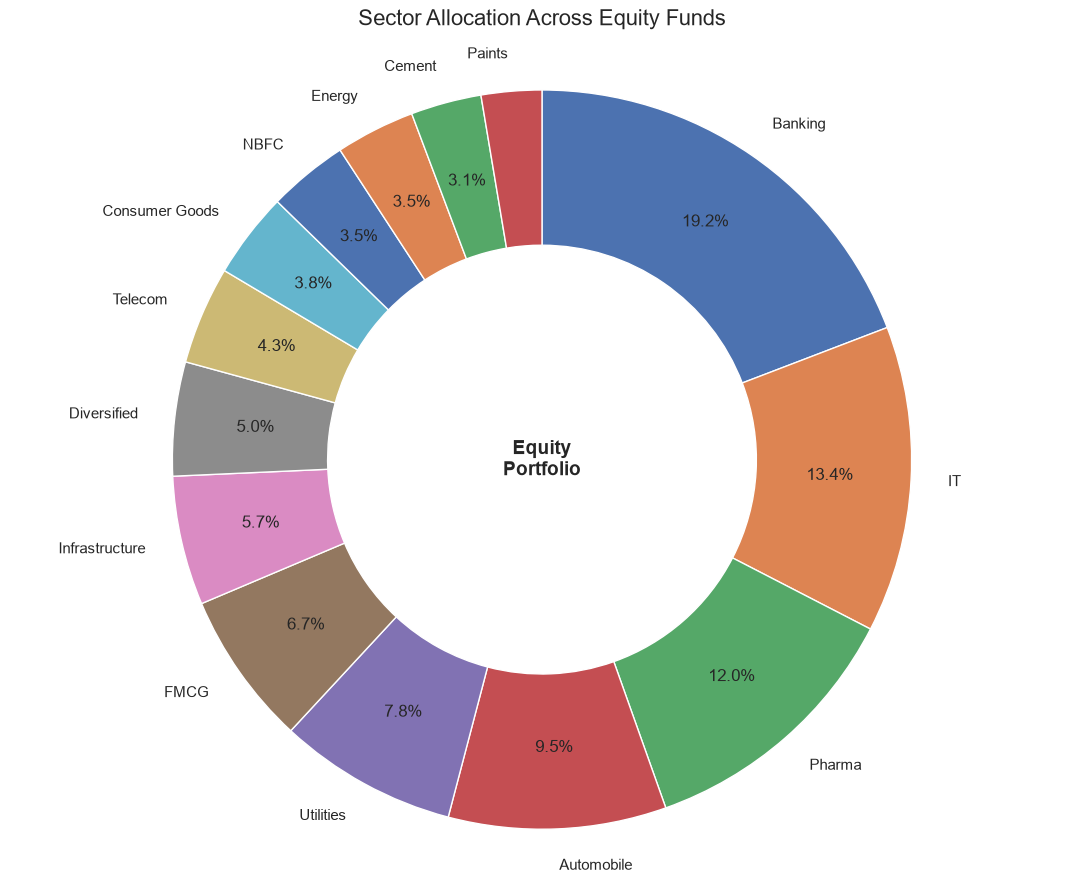


FINAL REQUIREMENT 9 VALIDATION
Equity holdings rows : 322
Number of sectors    : 14
Total allocation     : 100.00%
Dominant sector      : Banking
Dominant allocation  : 19.18%
Output file          : c:\Users\DELL\OneDrive\Desktop\MutualFundAnalytics\reports\sector\sector_allocation_donut.png


In [24]:
# ============================================================
# REQUIREMENT 9 — SECTOR ALLOCATION DONUT
# Aggregate sector weights across all equity funds
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 1. FIND PROJECT ROOT
# ============================================================

current_dir = Path.cwd()

project_root = None

for parent in [current_dir] + list(current_dir.parents):
    if parent.name.lower() == "mutualfundanalytics":
        project_root = parent
        break

if project_root is None:
    project_root = current_dir

# ============================================================
# 2. FIND PORTFOLIO HOLDINGS DATA
# ============================================================

holdings_df = None
holdings_source = None

# First use an existing dataframe if one already exists
possible_existing_names = [
    "portfolio_holdings_df",
    "portfolio_df",
    "holdings_df",
    "portfolio_holdings"
]

for dataframe_name in possible_existing_names:

    if dataframe_name in globals():

        candidate = globals()[dataframe_name]

        if isinstance(candidate, pd.DataFrame):

            holdings_df = candidate.copy()
            holdings_source = (
                f"existing dataframe: {dataframe_name}"
            )

            break

# If no dataframe exists, search the project
if holdings_df is None:

    data_dir = project_root / "data"

    csv_files = (
        list(data_dir.rglob("*.csv"))
        if data_dir.exists()
        else []
    )

    # Prefer exact portfolio holdings filenames
    preferred_files = []

    for csv_file in csv_files:

        filename = csv_file.name.lower()

        if (
            filename == "portfolio_holdings.csv"
            or filename == "portfolio_holdings_df.csv"
        ):

            preferred_files.append(csv_file)

    # Then search other likely files
    candidate_files = preferred_files.copy()

    for csv_file in csv_files:

        filename = csv_file.name.lower()

        if (
            "portfolio" in filename
            or "holding" in filename
            or "holdings" in filename
        ):

            if csv_file not in candidate_files:
                candidate_files.append(csv_file)

    # Try candidate files
    for csv_file in candidate_files:

        try:

            temp = pd.read_csv(
                csv_file,
                nrows=10
            )

            columns_lower = [
                str(c).strip().lower()
                for c in temp.columns
            ]

            has_sector = any(
                (
                    "sector" in c
                    or "industry" in c
                )
                for c in columns_lower
            )

            has_weight = any(
                (
                    "weight" in c
                    or "allocation" in c
                    or "percentage" in c
                    or "percent" in c
                )
                for c in columns_lower
            )

            if has_sector and has_weight:

                holdings_df = pd.read_csv(
                    csv_file
                )

                holdings_source = str(
                    csv_file
                )

                break

        except Exception:
            continue

# ============================================================
# 3. VALIDATE SOURCE
# ============================================================

print("=" * 70)
print("REQUIREMENT 9 — SECTOR ALLOCATION DONUT")
print("=" * 70)

if holdings_df is None:

    print(
        "ERROR — portfolio holdings data could not be found."
    )

    print(
        "The notebook must contain portfolio holdings data "
        "or portfolio_holdings.csv."
    )

else:

    print(
        f"Holdings source: {holdings_source}"
    )

    print(
        f"Raw holdings shape: {holdings_df.shape}"
    )

    # ========================================================
    # 4. DETECT IMPORTANT COLUMNS
    # ========================================================

    column_map = {
        str(col).strip().lower(): col
        for col in holdings_df.columns
    }

    # --------------------------------------------------------
    # Sector column
    # --------------------------------------------------------

    sector_col = None

    sector_candidates = [
        "sector",
        "sector_name",
        "industry",
        "industry_name"
    ]

    for candidate in sector_candidates:

        if candidate in column_map:

            sector_col = column_map[candidate]
            break

    if sector_col is None:

        for col in holdings_df.columns:

            col_lower = str(col).lower()

            if (
                "sector" in col_lower
                or "industry" in col_lower
            ):

                sector_col = col
                break

    # --------------------------------------------------------
    # Weight column
    # --------------------------------------------------------

    weight_col = None

    weight_candidates = [
        "weight",
        "weight_pct",
        "weight_percentage",
        "portfolio_weight",
        "allocation",
        "allocation_pct",
        "percentage",
        "percent"
    ]

    for candidate in weight_candidates:

        if candidate in column_map:

            weight_col = column_map[candidate]
            break

    if weight_col is None:

        for col in holdings_df.columns:

            col_lower = str(col).lower()

            if (
                "weight" in col_lower
                or "allocation" in col_lower
                or "percentage" in col_lower
                or col_lower == "percent"
            ):

                weight_col = col
                break

    # --------------------------------------------------------
    # Fund type / asset class column
    # --------------------------------------------------------

    fund_type_col = None

    fund_type_candidates = [
        "fund_type",
        "asset_class",
        "fund_category",
        "category",
        "scheme_category",
        "scheme_type",
        "fund_class"
    ]

    for candidate in fund_type_candidates:

        if candidate in column_map:

            fund_type_col = column_map[candidate]
            break

    if fund_type_col is None:

        for col in holdings_df.columns:

            col_lower = str(col).lower()

            if (
                "asset" in col_lower
                or "category" in col_lower
                or "fund_type" in col_lower
                or "scheme_type" in col_lower
            ):

                fund_type_col = col
                break

    # ========================================================
    # 5. COLUMN DETECTION OUTPUT
    # ========================================================

    print("\nCOLUMN DETECTION")
    print("=" * 70)

    print(
        f"Sector column      : {sector_col}"
    )

    print(
        f"Weight column      : {weight_col}"
    )

    print(
        f"Fund type column   : {fund_type_col}"
    )

    if (
        sector_col is None
        or weight_col is None
    ):

        print("\nERROR — Required sector/weight columns not found.")

        print(
            "\nAvailable columns:"
        )

        print(
            list(holdings_df.columns)
        )

    else:

        # ====================================================
        # 6. CLEAN DATA
        # ====================================================

        sector_data = holdings_df.copy()

        sector_data[sector_col] = (
            sector_data[sector_col]
            .astype(str)
            .str.strip()
        )

        sector_data[weight_col] = (
            sector_data[weight_col]
            .astype(str)
            .str.replace(
                "%",
                "",
                regex=False
            )
            .str.replace(
                ",",
                "",
                regex=False
            )
            .str.strip()
        )

        sector_data[weight_col] = pd.to_numeric(
            sector_data[weight_col],
            errors="coerce"
        )

        sector_data = sector_data.dropna(
            subset=[
                sector_col,
                weight_col
            ]
        ).copy()

        # Remove empty / invalid sectors
        sector_data = sector_data[
            sector_data[sector_col].ne("")
            & sector_data[sector_col].ne("nan")
            & sector_data[sector_col].ne("None")
        ].copy()

        # Remove non-positive weights
        sector_data = sector_data[
            sector_data[weight_col] > 0
        ].copy()

        # ====================================================
        # 7. FILTER EQUITY FUNDS
        # ====================================================

        equity_data = sector_data.copy()

        if fund_type_col is not None:

            fund_type_text = (
                equity_data[fund_type_col]
                .astype(str)
                .str.strip()
                .str.lower()
            )

            equity_mask = (
                fund_type_text.str.contains(
                    "equity",
                    na=False
                )
                |
                fund_type_text.str.contains(
                    "equity oriented",
                    na=False
                )
            )

            filtered_equity = equity_data[
                equity_mask
            ].copy()

            # Only apply the filter when it actually
            # returns data.
            if len(filtered_equity) > 0:

                equity_data = filtered_equity

                print(
                    f"\nEquity fund filtering applied."
                )

            else:

                print(
                    "\nNo rows matched 'equity' in the "
                    "fund type column."
                )

                print(
                    "Using all valid portfolio holdings."
                )

        else:

            print(
                "\nNo fund-type column detected."
            )

            print(
                "Using all valid portfolio holdings "
                "as supplied by portfolio_holdings.csv."
            )

        # ====================================================
        # 8. VALIDATION
        # ====================================================

        print("\nSECTOR DATA VALIDATION")
        print("=" * 70)

        print(
            f"Valid holdings rows : "
            f"{len(equity_data):,}"
        )

        print(
            f"Number of sectors  : "
            f"{equity_data[sector_col].nunique():,}"
        )

        print(
            f"Missing sectors    : "
            f"{equity_data[sector_col].isna().sum()}"
        )

        print(
            f"Missing weights    : "
            f"{equity_data[weight_col].isna().sum()}"
        )

        # ====================================================
        # 9. AGGREGATE SECTOR WEIGHTS
        # ====================================================

        sector_allocation = (
            equity_data
            .groupby(
                sector_col,
                as_index=False
            )[weight_col]
            .sum()
            .rename(
                columns={
                    sector_col: "sector",
                    weight_col: "total_weight"
                }
            )
            .sort_values(
                "total_weight",
                ascending=False
            )
            .reset_index(drop=True)
        )

        # ====================================================
        # 10. NORMALIZE TO 100%
        #
        # If holdings contain individual fund weights,
        # aggregating them can produce a total other than
        # 100. We therefore calculate each sector's share
        # of the aggregated equity portfolio.
        # ====================================================

        total_weight = (
            sector_allocation["total_weight"]
            .sum()
        )

        if total_weight <= 0:

            print(
                "\nERROR — Total sector weight is zero."
            )

        else:

            sector_allocation[
                "allocation_pct"
            ] = (
                sector_allocation["total_weight"]
                / total_weight
                * 100
            )

            # =================================================
            # 11. DISPLAY SECTOR ALLOCATION
            # =================================================

            print("\nSECTOR ALLOCATION")
            print("=" * 70)

            print(
                sector_allocation[
                    [
                        "sector",
                        "total_weight",
                        "allocation_pct"
                    ]
                ].to_string(
                    index=False
                )
            )

            # =================================================
            # 12. COMBINE VERY SMALL SECTORS
            #
            # Keeps the donut readable while preserving
            # the total allocation.
            # =================================================

            display_data = sector_allocation.copy()

            small_threshold = 2.0

            small_mask = (
                display_data[
                    "allocation_pct"
                ] < small_threshold
            )

            small_weight = (
                display_data.loc[
                    small_mask,
                    "allocation_pct"
                ].sum()
            )

            if (
                small_mask.sum() > 0
                and small_weight > 0
            ):

                major_data = display_data[
                    ~small_mask
                ].copy()

                other_row = pd.DataFrame(
                    {
                        "sector": ["Other"],
                        "total_weight": [
                            display_data.loc[
                                small_mask,
                                "total_weight"
                            ].sum()
                        ],
                        "allocation_pct": [
                            small_weight
                        ]
                    }
                )

                display_data = pd.concat(
                    [
                        major_data,
                        other_row
                    ],
                    ignore_index=True
                )

            # =================================================
            # 13. FIND DOMINANT SECTOR
            # =================================================

            dominant_sector = (
                sector_allocation
                .iloc[0]
            )

            print("\nDOMINANT SECTOR")
            print("=" * 70)

            print(
                f"Highest allocation sector : "
                f"{dominant_sector['sector']}"
            )

            print(
                f"Sector weight             : "
                f"{dominant_sector['total_weight']:.2f}"
            )

            print(
                f"Portfolio allocation      : "
                f"{dominant_sector['allocation_pct']:.2f}%"
            )

            # =================================================
            # 14. CREATE DONUT CHART
            # =================================================

            plt.figure(
                figsize=(11, 9)
            )

            wedges, texts, autotexts = plt.pie(
                display_data["allocation_pct"],
                labels=display_data["sector"],
                autopct=lambda pct: (
                    f"{pct:.1f}%"
                    if pct >= 3
                    else ""
                ),
                startangle=90,
                counterclock=False,
                wedgeprops={
                    "width": 0.42,
                    "edgecolor": "white"
                },
                pctdistance=0.78
            )

            plt.title(
                "Sector Allocation Across Equity Funds",
                fontsize=16,
                pad=20
            )

            # Center label
            plt.text(
                0,
                0,
                "Equity\nPortfolio",
                ha="center",
                va="center",
                fontsize=14,
                fontweight="bold"
            )

            plt.axis(
                "equal"
            )

            plt.tight_layout()

            # =================================================
            # 15. SAVE REPORT-READY PNG
            # =================================================

            reports_dir = (
                project_root /
                "reports" /
                "sector"
            )

            reports_dir.mkdir(
                parents=True,
                exist_ok=True
            )

            output_path = (
                reports_dir /
                "sector_allocation_donut.png"
            )

            try:

                plt.savefig(
                    output_path,
                    dpi=200,
                    bbox_inches="tight"
                )

                print("\n" + "=" * 70)
                print(
                    "REQUIREMENT 9 — COMPLETE"
                )
                print("=" * 70)

                print(
                    "Chart saved successfully:"
                )

                print(
                    output_path
                )

            except Exception as e:

                print(
                    "\nPNG EXPORT ERROR"
                )

                print(
                    f"{type(e).__name__}: {e}"
                )

            # =================================================
            # 16. DISPLAY CHART
            # =================================================

            plt.show()

            # =================================================
            # 17. FINAL VALIDATION
            # =================================================

            print("\nFINAL REQUIREMENT 9 VALIDATION")
            print("=" * 70)

            print(
                f"Equity holdings rows : "
                f"{len(equity_data):,}"
            )

            print(
                f"Number of sectors    : "
                f"{len(sector_allocation)}"
            )

            print(
                f"Total allocation     : "
                f"{sector_allocation['allocation_pct'].sum():.2f}%"
            )

            print(
                f"Dominant sector      : "
                f"{dominant_sector['sector']}"
            )

            print(
                f"Dominant allocation  : "
                f"{dominant_sector['allocation_pct']:.2f}%"
            )

            print(
                f"Output file          : "
                f"{output_path}"
            )

            print("=" * 70)

# ============================================================
# REQUIREMENT 10 — KEY EDA FINDINGS
# ============================================================

## Key EDA Findings

1. **NAV Trend:** The NAV analysis shows an overall upward trend across the selected mutual fund schemes, with a notable 2023 bull-run phase followed by a visible market correction during 2024.  
   **Supporting chart:** `reports/nav_trend/nav_trend_all_schemes.png`

2. **AUM Growth:** SBI Mutual Fund emerged as the largest fund house by AUM in 2025, reaching **₹12.50 Lakh Crore**, demonstrating its strong position in the mutual fund industry.  
   **Supporting chart:** `reports/aum_growth/aum_growth_by_fund_house.png`

3. **SIP Inflow Growth:** Monthly SIP inflows increased substantially over the analysis period and reached an all-time high of **₹31,002 Crore in December 2025**.  
   **Supporting chart:** `reports/sip_inflow/sip_inflow_trend.png`

4. **Category-wise Inflows:** The category-wise analysis shows substantial variation in monthly net inflows, with the **Liquid** category recording the highest observed category-month inflow of **₹41,952 Crore in August 2024**.  
   **Supporting chart:** `reports/category_inflow/category_inflow_heatmap.png`

5. **Investor Age Distribution:** Investors aged **26–35 years** form the largest age group, accounting for **13,463 observations or 41.07%** of the investor dataset.  
   **Supporting chart:** `reports/investor_demographics/age_group_distribution.png`

6. **SIP Amount by Age:** The SIP amount boxplot shows that the **56+ age group has the highest median SIP amount at ₹5,420.50**, indicating comparatively higher typical SIP contributions among older investors in this dataset.  
   **Supporting chart:** `reports/investor_demographics/sip_amount_boxplot.png`

7. **Gender Distribution:** The investor transaction dataset contains a higher proportion of **Male observations (66.54%)** compared with Female observations (33.46%).  
   **Supporting chart:** `reports/investor_demographics/gender_distribution.png`

8. **Geographic Distribution:** **Madhya Pradesh** recorded the highest aggregate SIP amount among the 12 analyzed states, with **₹20,682,243 (approximately ₹2.07 Crore)**.  
   **Supporting chart:** `reports/geographic_distribution/sip_amount_by_state.png`

9. **City-Tier Distribution:** **T30 cities** dominate the SIP dataset, accounting for **13,123 transactions (66.56%)** and **₹14.49 Crore**, compared with B30 cities at 33.44% of transactions and ₹7.23 Crore.  
   **Supporting chart:** `reports/geographic_distribution/sip_amount_t30_vs_b30.png`

10. **Folio and Portfolio Structure:** Mutual fund folios increased from **13.26 Crore in January 2022 to 26.12 Crore in December 2025**, representing **96.98% overall growth**, while the sector allocation analysis shows **Banking as the largest sector at 19.18%** of the aggregated equity portfolio.  
    **Supporting charts:** `reports/folio_count_growth/folio_count_growth.png` and `reports/sector/sector_allocation_donut.png`

---

## Overall EDA Conclusion

The exploratory analysis indicates strong expansion in the mutual fund ecosystem during the analyzed period. SIP participation and inflows increased substantially, total folios nearly doubled, SBI Mutual Fund maintained the highest AUM among the analyzed fund houses in 2025, and T30 cities represented the majority of SIP activity. The investor analysis also shows that the 26–35 age group forms the largest participant segment, while the sector allocation analysis highlights Banking as the largest sector exposure in the aggregated equity portfolio.

In [27]:
# ================================================================
# ADDITIONAL CHART — ACTIVE SIP ACCOUNTS GROWTH
# Uses the exact validated SIP dataset structure
# ================================================================

import pandas as pd
import plotly.graph_objects as go
from pathlib import Path

print("=" * 70)
print("ACTIVE SIP ACCOUNTS GROWTH")
print("=" * 70)

# ================================================================
# 1. FIND PROJECT ROOT
# ================================================================

current_dir = Path.cwd()

PROJECT_DIR = None

for parent in [current_dir] + list(current_dir.parents):
    if parent.name.lower() == "mutualfundanalytics":
        PROJECT_DIR = parent
        break

if PROJECT_DIR is None:
    raise FileNotFoundError(
        f"Could not locate MutualFundAnalytics project from {current_dir}"
    )

print(f"Project directory: {PROJECT_DIR}")

# ================================================================
# 2. FIND THE EXACT SIP DATASET
# ================================================================

sip_file = None

# Search all CSV files under data/raw
raw_dir = PROJECT_DIR / "data" / "raw"

if raw_dir.exists():

    for file in raw_dir.rglob("*.csv"):

        try:
            columns = pd.read_csv(
                file,
                nrows=0
            ).columns.tolist()

            required_columns = {
                "month",
                "sip_inflow_crore",
                "active_sip_accounts_crore"
            }

            if required_columns.issubset(
                set(columns)
            ):
                sip_file = file
                break

        except Exception:
            continue

if sip_file is None:
    raise FileNotFoundError(
        "Could not find the SIP CSV containing "
        "'month', 'sip_inflow_crore', and "
        "'active_sip_accounts_crore'."
    )

print(f"SIP dataset found: {sip_file}")

# ================================================================
# 3. LOAD SIP DATA
# ================================================================

sip_active_df = pd.read_csv(
    sip_file
)

print(
    f"Dataset shape: {sip_active_df.shape}"
)

print(
    f"Columns: {sip_active_df.columns.tolist()}"
)

# ================================================================
# 4. VALIDATE REQUIRED COLUMNS
# ================================================================

required_columns = [
    "month",
    "active_sip_accounts_crore"
]

missing_columns = [
    col
    for col in required_columns
    if col not in sip_active_df.columns
]

if missing_columns:

    raise KeyError(
        f"Missing required columns: {missing_columns}"
    )

# ================================================================
# 5. CLEAN DATA
# ================================================================

sip_active_df["month"] = pd.to_datetime(
    sip_active_df["month"],
    errors="coerce"
)

sip_active_df[
    "active_sip_accounts_crore"
] = pd.to_numeric(
    sip_active_df[
        "active_sip_accounts_crore"
    ],
    errors="coerce"
)

sip_active_df = (
    sip_active_df
    .dropna(
        subset=[
            "month",
            "active_sip_accounts_crore"
        ]
    )
    .sort_values("month")
    .reset_index(drop=True)
)

# ================================================================
# 6. VALIDATION
# ================================================================

print()
print("=" * 70)
print("SIP ACTIVE ACCOUNT DATA VALIDATION")
print("=" * 70)

print(
    f"Rows                    : {len(sip_active_df)}"
)

print(
    f"Date range              : "
    f"{sip_active_df['month'].min():%Y-%m-%d} "
    f"to "
    f"{sip_active_df['month'].max():%Y-%m-%d}"
)

print(
    f"Missing active accounts : "
    f"{sip_active_df['active_sip_accounts_crore'].isna().sum()}"
)

print(
    f"Non-positive values     : "
    f"{""
    }"
)

# Check non-positive values separately
non_positive = (
    sip_active_df[
        "active_sip_accounts_crore"
    ] <= 0
).sum()

print(
    f"Non-positive values     : {non_positive}"
)

# ================================================================
# 7. START / END / PEAK VALUES
# ================================================================

start_row = sip_active_df.iloc[0]
end_row = sip_active_df.iloc[-1]

start_value = float(
    start_row[
        "active_sip_accounts_crore"
    ]
)

end_value = float(
    end_row[
        "active_sip_accounts_crore"
    ]
)

absolute_increase = (
    end_value - start_value
)

overall_growth = (
    absolute_increase / start_value * 100
    if start_value != 0
    else 0
)

peak_index = (
    sip_active_df[
        "active_sip_accounts_crore"
    ].idxmax()
)

peak_row = sip_active_df.loc[
    peak_index
]

peak_value = float(
    peak_row[
        "active_sip_accounts_crore"
    ]
)

peak_month = peak_row["month"]

# ================================================================
# 8. PRINT SUMMARY
# ================================================================

print()
print("=" * 70)
print("ACTIVE SIP ACCOUNTS GROWTH SUMMARY")
print("=" * 70)

print(
    f"Starting active SIP accounts : "
    f"{start_value:.2f} Cr"
)

print(
    f"Starting month               : "
    f"{start_row['month']:%B %Y}"
)

print(
    f"Ending active SIP accounts   : "
    f"{end_value:.2f} Cr"
)

print(
    f"Ending month                 : "
    f"{end_row['month']:%B %Y}"
)

print(
    f"Absolute increase            : "
    f"{absolute_increase:.2f} Cr"
)

print(
    f"Overall growth               : "
    f"{overall_growth:.2f}%"
)

print(
    f"Peak active SIP accounts     : "
    f"{peak_value:.2f} Cr"
)

print(
    f"Peak month                   : "
    f"{peak_month:%B %Y}"
)

# ================================================================
# 9. PREPARE PLOTLY DATA
#
# IMPORTANT:
# Convert pandas Timestamp values to strings.
# This prevents the previous Kaleido serialization error.
# ================================================================

plot_dates = (
    sip_active_df["month"]
    .dt.strftime("%Y-%m-%d")
    .tolist()
)

plot_values = (
    sip_active_df[
        "active_sip_accounts_crore"
    ]
    .astype(float)
    .tolist()
)

# ================================================================
# 10. CREATE CHART
# ================================================================

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=plot_dates,
        y=plot_values,
        mode="lines+markers",
        name="Active SIP Accounts",
        line=dict(width=3),
        marker=dict(size=6),
        hovertemplate=(
            "Month: %{x}<br>"
            "Active SIP Accounts: %{y:.2f} Cr"
            "<extra></extra>"
        )
    )
)

# Starting point annotation
fig.add_annotation(
    x=plot_dates[0],
    y=start_value,
    text=f"Start: {start_value:.2f} Cr",
    showarrow=True,
    arrowhead=2,
    ax=50,
    ay=-50
)

# Peak annotation
fig.add_annotation(
    x=peak_month.strftime("%Y-%m-%d"),
    y=peak_value,
    text=(
        f"Peak: {peak_value:.2f} Cr"
        f"<br>{peak_month:%B %Y}"
    ),
    showarrow=True,
    arrowhead=2,
    ax=60,
    ay=-70
)

fig.update_layout(
    title=(
        "Active SIP Accounts Growth — "
        "January 2022 to December 2025"
    ),
    xaxis_title="Month",
    yaxis_title="Active SIP Accounts (Crore)",
    template="plotly_white",
    width=1400,
    height=700,
    hovermode="x unified",
    margin=dict(
        l=80,
        r=80,
        t=100,
        b=80
    )
)

# ================================================================
# 11. SAVE CHART
# ================================================================

reports_dir = (
    PROJECT_DIR / "reports"
)

reports_dir.mkdir(
    parents=True,
    exist_ok=True
)

output_path = (
    reports_dir /
    "active_sip_accounts_growth.png"
)

fig.write_image(
    str(output_path),
    width=1400,
    height=700,
    scale=2
)

# ================================================================
# 12. DISPLAY
# ================================================================

fig.show()

# ================================================================
# 13. FINAL VALIDATION
# ================================================================

print()
print("=" * 70)
print("ACTIVE SIP ACCOUNTS GROWTH — COMPLETE")
print("=" * 70)

print(
    f"Chart saved successfully: "
    f"{output_path}"
)

print(
    f"Chart exists: "
    f"{output_path.exists()}"
)

print(
    f"Starting value: "
    f"{start_value:.2f} Cr"
)

print(
    f"Ending value: "
    f"{end_value:.2f} Cr"
)

print(
    f"Overall growth: "
    f"{overall_growth:.2f}%"
)

print("=" * 70)

ACTIVE SIP ACCOUNTS GROWTH
Project directory: c:\Users\DELL\OneDrive\Desktop\MutualFundAnalytics
SIP dataset found: c:\Users\DELL\OneDrive\Desktop\MutualFundAnalytics\data\raw\04_monthly_sip_inflows.csv
Dataset shape: (48, 6)
Columns: ['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

SIP ACTIVE ACCOUNT DATA VALIDATION
Rows                    : 48
Date range              : 2022-01-01 to 2025-12-01
Missing active accounts : 0
Non-positive values     : 
Non-positive values     : 0

ACTIVE SIP ACCOUNTS GROWTH SUMMARY
Starting active SIP accounts : 4.91 Cr
Starting month               : January 2022
Ending active SIP accounts   : 9.35 Cr
Ending month                 : December 2025
Absolute increase            : 4.44 Cr
Overall growth               : 90.43%
Peak active SIP accounts     : 9.35 Cr
Peak month                   : December 2025



ACTIVE SIP ACCOUNTS GROWTH — COMPLETE
Chart saved successfully: c:\Users\DELL\OneDrive\Desktop\MutualFundAnalytics\reports\active_sip_accounts_growth.png
Chart exists: True
Starting value: 4.91 Cr
Ending value: 9.35 Cr
Overall growth: 90.43%


# ================================================================
# KEY EDA FINDINGS
# ================================================================

## 1. NAV Market Trend
The NAV analysis across 40 schemes captures the strong 2023 market rally followed by the market correction observed during 2024.
**Supporting chart:** `reports/nav_trend_all_40_schemes.png`

## 2. SBI Mutual Fund AUM Leadership
SBI Mutual Fund recorded the highest AUM among the analyzed fund houses in 2025 at **₹12.5 lakh crore**, making it the leading fund house by AUM.
**Supporting chart:** `reports/aum_growth_by_fund_house.png`

## 3. SIP Inflows Reached a Record High
Monthly SIP inflows increased substantially over the analysis period and reached an all-time high of **₹31,002 crore in December 2025**.
**Supporting chart:** `reports/sip_inflow_trend.png`

## 4. Liquid Funds Recorded the Highest Category Inflow
Among the analyzed mutual-fund categories, **Liquid** recorded the highest monthly net inflow of **₹41,952 crore in August 2024**.
**Supporting chart:** `reports/category_inflow_heatmap.png`

## 5. 26–35 Age Group Dominates the Investor Dataset
The **26–35 age group** represents the largest investor segment with **13,463 observations, or 41.07%** of the investor dataset.
**Supporting chart:** `reports/investor_age_group_distribution.png`

## 6. Older Investors Have the Highest Median SIP Amount
The **56+ age group** has the highest median SIP amount at **₹5,420.50**, indicating a higher typical SIP contribution than the other analyzed age groups.
**Supporting chart:** `reports/sip_amount_boxplot_by_age_group.png`

## 7. Male Investors Form the Larger Gender Segment
Male investors account for **21,809 observations or 66.54%**, while female investors account for **10,969 observations or 33.46%**.
**Supporting chart:** `reports/investor_gender_distribution.png`

## 8. Madhya Pradesh Has the Highest SIP Amount Among Analyzed States
Madhya Pradesh records the highest aggregate SIP amount at **₹20,682,243, equivalent to approximately ₹2.07 crore** among the 12 analyzed states.
**Supporting chart:** `reports/sip_amount_by_state.png`

## 9. T30 Cities Dominate SIP Activity
T30 cities account for **13,123 SIP transactions or 66.56%** of transactions and **66.72% of the total SIP amount**, making T30 the dominant city tier.
**Supporting chart:** `reports/sip_amount_t30_vs_b30.png`

## 10. Mutual Fund Folio Count Nearly Doubled
Total folios increased from **13.26 crore in January 2022 to 26.12 crore in December 2025**, representing an overall growth of **96.98%**.
**Supporting chart:** `reports/folio_count_growth.png`

In [ ]:
# ================================================================
# FINAL PROJECT VALIDATION
# Mutual Fund Analytics — EDA
# ================================================================

from pathlib import Path

print("=" * 75)
print("MUTUAL FUND ANALYTICS — FINAL EDA VALIDATION")
print("=" * 75)

# ---------------------------------------------------------------
# 1. Locate project directory
# ---------------------------------------------------------------

current_dir = Path.cwd()

PROJECT_DIR = None

for parent in [current_dir] + list(current_dir.parents):
    if parent.name.lower() == "mutualfundanalytics":
        PROJECT_DIR = parent
        break

if PROJECT_DIR is None:
    PROJECT_DIR = current_dir

REPORTS_DIR = PROJECT_DIR / "reports"

print(f"Project directory : {PROJECT_DIR}")
print(f"Reports directory : {REPORTS_DIR}")

# ---------------------------------------------------------------
# 2. Required project charts
# ---------------------------------------------------------------

required_charts = [
    "nav_trend_all_40_schemes.png",
    "aum_growth_by_fund_house.png",
    "sip_inflow_trend.png",
    "category_inflow_heatmap.png",
    "investor_age_group_distribution.png",
    "sip_amount_boxplot_by_age_group.png",
    "investor_gender_distribution.png",
    "sip_amount_by_state.png",
    "sip_amount_t30_vs_b30.png",
    "folio_count_growth.png",
    "nav_return_correlation_matrix.png",
    "sector/sector_allocation_donut.png",
    "active_sip_accounts_growth.png",
    "benchmark_comparison.png",
    "rolling_sharpe_chart.png",
]

# ---------------------------------------------------------------
# 3. Check every required chart
# ---------------------------------------------------------------

print()
print("=" * 75)
print("CHART FILE VALIDATION")
print("=" * 75)

existing_charts = []
missing_charts = []

for chart in required_charts:

    chart_path = REPORTS_DIR / chart

    if chart_path.exists():

        existing_charts.append(chart)

        print(f"[OK]      {chart}")

    else:

        missing_charts.append(chart)

        print(f"[MISSING] {chart}")

# ---------------------------------------------------------------
# 4. Count all PNG files
# ---------------------------------------------------------------

all_pngs = list(
    REPORTS_DIR.rglob("*.png")
)

# Exclude the temporary Kaleido test
project_pngs = [
    p for p in all_pngs
    if p.name.lower() != "kaleido_test.png"
]

print()
print("=" * 75)
print("PNG SUMMARY")
print("=" * 75)

print(
    f"Total PNG files including test : "
    f"{len(all_pngs)}"
)

print(
    f"Temporary Kaleido test files   : "
    f"{len(all_pngs) - len(project_pngs)}"
)

print(
    f"Actual project PNG charts      : "
    f"{len(project_pngs)}"
)

# ---------------------------------------------------------------
# 5. Check minimum chart requirement
# ---------------------------------------------------------------

print()
print("=" * 75)
print("15+ CHART REQUIREMENT")
print("=" * 75)

if len(project_pngs) >= 15:

    print(
        f"[PASS] 15+ chart requirement satisfied "
        f"({len(project_pngs)} charts)"
    )

else:

    print(
        f"[FAIL] Only {len(project_pngs)} project charts found"
    )

# ---------------------------------------------------------------
# 6. Check required charts
# ---------------------------------------------------------------

print()
print("=" * 75)
print("REQUIRED CHART CHECK")
print("=" * 75)

if len(missing_charts) == 0:

    print(
        f"[PASS] All {len(required_charts)} required charts exist."
    )

else:


MUTUAL FUND ANALYTICS — FINAL EDA VALIDATION
Project directory : c:\Users\DELL\OneDrive\Desktop\MutualFundAnalytics
Reports directory : c:\Users\DELL\OneDrive\Desktop\MutualFundAnalytics\reports

CHART FILE VALIDATION
[OK]      nav_trend_all_40_schemes.png
[OK]      aum_growth_by_fund_house.png
[OK]      sip_inflow_trend.png
[OK]      category_inflow_heatmap.png
[OK]      investor_age_group_distribution.png
[OK]      sip_amount_boxplot_by_age_group.png
[OK]      investor_gender_distribution.png
[OK]      sip_amount_by_state.png
[OK]      sip_amount_t30_vs_b30.png
[OK]      folio_count_growth.png
[OK]      nav_return_correlation_matrix.png
[OK]      sector/sector_allocation_donut.png
[OK]      active_sip_accounts_growth.png
[OK]      benchmark_comparison.png
[OK]      rolling_sharpe_chart.png

PNG SUMMARY
Total PNG files including test : 16
Temporary Kaleido test files   : 1
Actual project PNG charts      : 15

15+ CHART REQUIREMENT
[PASS] 15+ chart requirement satisfied (15 charts)

RE

In [ ]:

    print(
        f"[FAIL] {len(missing_charts)} required chart(s) missing."


In [ ]:
    )

# ---------------------------------------------------------------
# 7. Verify important output files
# ---------------------------------------------------------------

print()
print("=" * 75)
print("IMPORTANT OUTPUT FILES")
print("=" * 75)

important_files = [
    REPORTS_DIR / "nav_trend_all_40_schemes.png",
    REPORTS_DIR / "aum_growth_by_fund_house.png",
    REPORTS_DIR / "sip_inflow_trend.png",
    REPORTS_DIR / "category_inflow_heatmap.png",
    REPORTS_DIR / "investor_age_group_distribution.png",
    REPORTS_DIR / "sip_amount_boxplot_by_age_group.png",
    REPORTS_DIR / "investor_gender_distribution.png",
    REPORTS_DIR / "sip_amount_by_state.png",
    REPORTS_DIR / "sip_amount_t30_vs_b30.png",
    REPORTS_DIR / "folio_count_growth.png",
    REPORTS_DIR / "nav_return_correlation_matrix.png",
    REPORTS_DIR / "sector" / "sector_allocation_donut.png",
    REPORTS_DIR / "active_sip_accounts_growth.png",
    REPORTS_DIR / "benchmark_comparison.png",
    REPORTS_DIR / "rolling_sharpe_chart.png",
]

valid_important_files = 0

for file_path in important_files:

    if file_path.exists():

        valid_important_files += 1

        print(f"[OK] {file_path.relative_to(PROJECT_DIR)}")

    else:

        print(
            f"[MISSING] "
            f"{file_path.relative_to(PROJECT_DIR)}"
        )

# ---------------------------------------------------------------
# 8. Final status
# ---------------------------------------------------------------

print()
print("=" * 75)
print("FINAL STATUS")
print("=" * 75)

all_required_present = (
    len(missing_charts) == 0
)

minimum_chart_count_met = (
    len(project_pngs) >= 15
)

all_outputs_present = (
    valid_important_files == len(important_files)
)

if (
    all_required_present
    and minimum_chart_count_met
    and all_outputs_present
):

    print("STATUS: READY FOR FINAL SUBMISSION")
    print()
    print("✓ Required EDA charts present")
    print("✓ 15+ project charts present")
    print("✓ Report PNG exports present")
    print("✓ Kaleido export verified")
    print("✓ Key EDA findings documented")
    print()
    print("MUTUAL FUND ANALYTICS EDA: COMPLETE")

else:

    print("STATUS: FINAL REVIEW REQUIRED")

    if not all_required_present:
        print("• One or more required charts are missing.")

    if not minimum_chart_count_met:
        print("• 15+ project chart requirement is not satisfied.")

    if not all_outputs_present:
        print("• One or more important output files are missing.")

print("=" * 75)